# QSAR and Machine Learning Analysis of Coumarin-Based Compounds

## 1. Dataset and Experimental Activity Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv(
    "lps_induced_no_qsar_dataset.csv"
)

print("Dataset loaded successfully!")
print("Number of compounds:", len(df))

Dataset loaded successfully!
Number of compounds: 34


In [3]:
# Standardize column names used in the original analysis
df["Smiles"] = df["SMILES"]
df["IC50 (μM)"] = df["IC50_uM"]
df["SD (μM)"] = df["SD_uM"]
df["Ref"] = df["Reference"]

print(df.head())

   ID Compound                                             SMILES  IC50_uM  \
0   1       K1  O=C(C(C(C)(C)C=C)=C1)OC2=C1C=C(C[C@@H](C(C)(O)...     0.52   
1   2       K2  O=C(C(C(C)(C)C=C)=C1)OC2=C1C=C(C[C@@H](O)C(C)(...     2.58   
2   3       K3  O=C(C(C(C)(C)C=C)=C1)OC2=C1C=C([C@H](O)[C@@H](...     1.06   
3   4       K4    O=C(C=C1)OC2=C1C=C(C/C=C(C)/C)C(O)=C2C/C=C(C)\C     5.49   
4   5       K5    O=C(C=C1)OC2=C1C=C(C[C@@H](OC)C(C)(O)C)C(OC)=C2     7.39   

   SD_uM   pIC50 Reference                                             Smiles  \
0   0.05  6.2840        R1  O=C(C(C(C)(C)C=C)=C1)OC2=C1C=C(C[C@@H](C(C)(O)...   
1   0.10  5.5884        R1  O=C(C(C(C)(C)C=C)=C1)OC2=C1C=C(C[C@@H](O)C(C)(...   
2   0.07  5.9747        R1  O=C(C(C(C)(C)C=C)=C1)OC2=C1C=C([C@H](O)[C@@H](...   
3   0.13  5.2604        R1    O=C(C=C1)OC2=C1C=C(C/C=C(C)/C)C(O)=C2C/C=C(C)\C   
4   0.16  5.1314        R1    O=C(C=C1)OC2=C1C=C(C[C@@H](OC)C(C)(O)C)C(OC)=C2   

   IC50 (μM)  SD (μM) Ref  
0       0.52    

## 2. Molecular Structure Preparation

In [4]:
df["Mol"] = df["Smiles"].apply(Chem.MolFromSmiles)

## 3. Molecular Structure Validation

In [5]:
print("Valid molecules:", df["Mol"].notna().sum())

Valid molecules: 34


In [6]:
print("Invalid molecules:", df["Mol"].isna().sum())

Invalid molecules: 0


## 4. Molecular Descriptor Calculation

Molecular descriptors were calculated using RDKit to characterize the physicochemical and structural properties of the coumarin-based compounds. The calculated descriptors include molecular weight, LogP, topological polar surface area (TPSA), hydrogen-bond donors and acceptors, rotatable bonds, ring counts, aromatic rings, and fraction of sp³-hybridized carbon atoms.

In [7]:
df["MolWt"] = df["Mol"].apply(Descriptors.MolWt)
df["LogP"] = df["Mol"].apply(Crippen.MolLogP)
df["TPSA"] = df["Mol"].apply(rdMolDescriptors.CalcTPSA)
df["HBD"] = df["Mol"].apply(Lipinski.NumHDonors)
df["HBA"] = df["Mol"].apply(Lipinski.NumHAcceptors)
df["RotatableBonds"] = df["Mol"].apply(Lipinski.NumRotatableBonds)
df["RingCount"] = df["Mol"].apply(Lipinski.RingCount)
df["AromaticRings"] = df["Mol"].apply(Lipinski.NumAromaticRings)
df["FractionCSP3"] = df["Mol"].apply(rdMolDescriptors.CalcFractionCSP3)

print("Descriptors generated successfully!")

Descriptors generated successfully!


### 4.1 Basic Molecular Descriptors

The calculated molecular descriptors were summarized to examine the physicochemical characteristics and structural diversity of the dataset.

In [8]:
descriptor_cols = [
    "Compound",
    "MolWt",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "AromaticRings",
    "FractionCSP3"
]

df[descriptor_cols].head(10)

,Compound,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount,AromaticRings,FractionCSP3
0,K1,382.500,4.8397,59.67,1,4,5,3,2,0.458333
1,K2,332.396,2.6365,90.90,3,5,5,2,2,0.421053
2,K3,330.380,2.8219,79.90,2,5,3,3,2,0.421053
3,K4,298.382,4.5160,50.44,1,3,4,2,2,0.315789
4,K5,292.331,2.1300,68.90,1,5,5,2,2,0.437500
5,K6,262.261,1.3811,87.74,2,5,3,2,2,0.285714
6,K7,228.247,2.6726,39.44,0,3,1,3,2,0.214286
7,K8,244.246,1.6450,59.67,1,4,2,3,2,0.214286
8,K9,244.246,2.3782,59.67,1,4,1,3,2,0.214286
9,K10,244.246,2.6828,59.67,1,4,0,3,2,0.214286


### 4.2 Descriptor Statistics and Data Quality Assessment

Descriptive statistics were calculated for the molecular descriptors to assess their distributions, ranges, and variability across the 34 compounds. Missing-value analysis was also performed to verify the completeness of the descriptor dataset.

In [9]:
basic_descriptors = [
    "MolWt",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "AromaticRings",
    "FractionCSP3"
]

summary = df[basic_descriptors].describe().T

summary

,count,mean,std,min,25%,50%,75%,max
MolWt,34.0,366.816735,92.926864,228.2470,293.843750,358.39000,432.217500,552.53500
LogP,34.0,4.198985,1.771756,1.3583,2.717575,3.91910,5.773250,7.02700
TPSA,34.0,78.614706,18.745738,39.4400,61.187500,81.34500,89.880000,123.79000
HBD,34.0,0.941176,0.736131,0.0000,0.250000,1.00000,1.000000,3.00000
HBA,34.0,5.382353,1.326072,3.0000,5.000000,5.00000,6.000000,9.00000
RotatableBonds,34.0,5.176471,4.056201,0.0000,3.000000,4.50000,6.000000,17.00000
RingCount,34.0,3.382353,1.348730,2.0000,2.000000,3.00000,5.000000,6.00000
AromaticRings,34.0,3.058824,1.455214,2.0000,2.000000,2.00000,4.500000,6.00000
FractionCSP3,34.0,0.281879,0.180545,0.0000,0.147321,0.30625,0.415789,0.62069


In [10]:
df[basic_descriptors].isna().sum()

MolWt             0
LogP              0
TPSA              0
HBD               0
HBA               0
RotatableBonds    0
RingCount         0
AromaticRings     0
FractionCSP3      0
dtype: int64

In [11]:
df["pIC50"].describe()

count    34.000000
mean      4.755491
std       0.669158
min       3.754000
25%       4.199275
50%       4.514550
75%       5.242900
max       6.284000
Name: pIC50, dtype: float64

In [12]:
df.loc[
    df["LogP"].nlargest(3).index,
    ["ID", "Compound", "LogP", "MolWt", "RotatableBonds", "TPSA"]
]

,ID,Compound,LogP,MolWt,RotatableBonds,TPSA
23,24,K24,7.0270,470.650,16,68.90
25,26,K26,7.0036,502.648,17,91.27
24,25,K25,6.9950,472.622,16,82.04


In [13]:
df.loc[
    df["RotatableBonds"].nlargest(3).index,
    ["ID", "Compound", "LogP", "MolWt", "RotatableBonds", "TPSA"]
]

,ID,Compound,LogP,MolWt,RotatableBonds,TPSA
25,26,K26,7.0036,502.648,17,91.27
23,24,K24,7.0270,470.650,16,68.90
24,25,K25,6.9950,472.622,16,82.04


In [14]:
descriptor_functions = Descriptors.descList

In [15]:
print("Number of descriptors available:", len(descriptor_functions))

Number of descriptors available: 217


### 4.3 Extended RDKit Molecular Descriptors
In addition to the selected physicochemical descriptors, an extended set of molecular descriptors available through RDKit was calculated for subsequent descriptor-based QSAR modeling. Descriptors that could not be calculated for the dataset were excluded during preprocessing.

In [16]:
descriptor_data = {}

for name, func in descriptor_functions:
    try:
        descriptor_data[name] = df["Mol"].apply(func)
    except Exception as e:
        print(f"Could not calculate {name}: {e}")

In [17]:
rdkit_desc = pd.DataFrame(descriptor_data)

In [18]:
print("Descriptor matrix shape:", rdkit_desc.shape)

Descriptor matrix shape: (34, 217)


In [19]:
import numpy as np

In [20]:
missing = rdkit_desc.isna().sum()

In [21]:
infinite = np.isinf(rdkit_desc).sum()

In [22]:
print("Total missing values:", missing.sum())
print("Total infinite values:", infinite.sum())

Total missing values: 0
Total infinite values: 0


In [23]:
print("\nDescriptors with missing values:")
print(missing[missing > 0])


Descriptors with missing values:
Series([], dtype: int64)


In [24]:
nunique = rdkit_desc.nunique()

In [25]:
constant_descriptors = nunique[nunique <= 1]

In [26]:
print("Number of constant descriptors:", len(constant_descriptors))
print("\nConstant descriptors:")
print(constant_descriptors.index.tolist())

Number of constant descriptors: 73

Constant descriptors:
['NumRadicalElectrons', 'PEOE_VSA4', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA8', 'SlogP_VSA9', 'EState_VSA11', 'NumAmideBonds', 'NumBridgeheadAtoms', 'NumSaturatedCarbocycles', 'NumUnspecifiedAtomStereoCenters', 'fr_Al_COO', 'fr_ArN', 'fr_Ar_COO', 'fr_Ar_N', 'fr_Ar_NH', 'fr_COO', 'fr_COO2', 'fr_C_S', 'fr_HOCCN', 'fr_Imine', 'fr_NH1', 'fr_NH2', 'fr_N_O', 'fr_Ndealkylation1', 'fr_Ndealkylation2', 'fr_Nhpyrrole', 'fr_SH', 'fr_aldehyde', 'fr_alkyl_carbamate', 'fr_alkyl_halide', 'fr_amide', 'fr_amidine', 'fr_aniline', 'fr_azide', 'fr_azo', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_epoxide', 'fr_guanido', 'fr_hdrzine', 'fr_hdrzone', 'fr_imidazole', 'fr_imide', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_lactone', 'fr_morpholine', 'fr_nitrile', 'fr_nitro_arom_nonortho', 'fr_nitroso', 'fr_oxazole', 'fr_oxime', 'fr_phos_acid', 'fr_phos_ester', 'fr_piperdine', 'fr_piperzine', 'fr_priamide', 'fr_prisulfonamd', 

In [27]:
rdkit_desc_clean = rdkit_desc.drop(columns=constant_descriptors.index)

In [28]:
print("Original descriptors:", rdkit_desc.shape[1])
print("Constant descriptors removed:", len(constant_descriptors))
print("Remaining descriptors:", rdkit_desc_clean.shape[1])

Original descriptors: 217
Constant descriptors removed: 73
Remaining descriptors: 144


In [29]:
import matplotlib.pyplot as plt

## 5. Biological Activity Analysis

The experimentally reported IC50 values were converted to pIC50 values and analyzed to characterize the biological activity distribution of the dataset before QSAR model development.

### 5.1 Distribution of pIC50 Values

The distribution of pIC50 values was examined to assess the range and variation of biological activity across the 34 compounds.

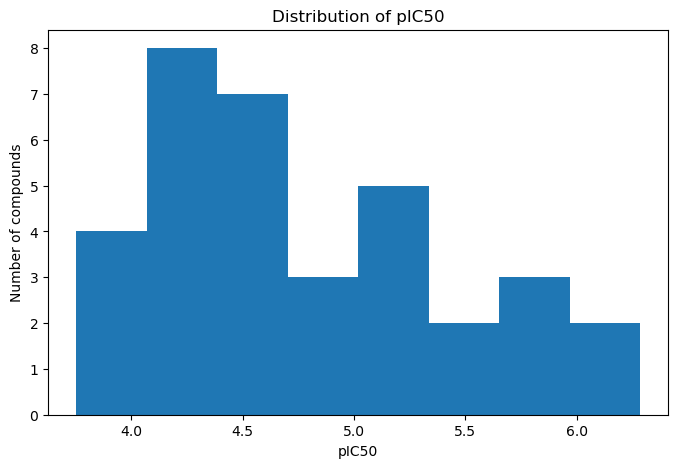

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(df["pIC50"], bins=8)
plt.xlabel("pIC50")
plt.ylabel("Number of compounds")
plt.title("Distribution of pIC50")
plt.show()

### 5.2 Descriptive Statistics of pIC50

In [31]:
df[["ID", "Compound", "pIC50"]].sort_values("pIC50")

,ID,Compound,pIC50
19,20,K20,3.7540
13,14,K14,3.8536
21,22,K22,4.0367
12,13,K13,4.0453
20,21,K21,4.1090
22,23,K23,4.1343
17,18,K18,4.1537
14,15,K15,4.1805
28,29,K29,4.1871
15,16,K16,4.2358


In [32]:
from sklearn.model_selection import train_test_split

In [33]:
activity_bins = pd.qcut(
    df["pIC50"],
    q=4,
    labels=False,
    duplicates="drop"
)

In [34]:
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=activity_bins
)

In [35]:
print("Training compounds:", len(train_df))
print("External test compounds:", len(test_df))

Training compounds: 27
External test compounds: 7


In [36]:
print("\nTraining pIC50 range:")
print(train_df["pIC50"].min(), "to", train_df["pIC50"].max())


Training pIC50 range:
3.8536 to 6.284


In [37]:
print("\nTest pIC50 range:")
print(test_df["pIC50"].min(), "to", test_df["pIC50"].max())


Test pIC50 range:
3.754 to 5.5884


In [38]:
test_df[["ID", "Compound", "pIC50"]].sort_values("pIC50")

,ID,Compound,pIC50
19,20,K20,3.7540
17,18,K18,4.1537
31,32,K32,4.3737
26,27,K27,4.4089
32,33,K33,4.5436
9,10,K10,5.3072
1,2,K2,5.5884


In [39]:
train_df[["ID", "Compound", "pIC50"]].sort_values("pIC50")

,ID,Compound,pIC50
13,14,K14,3.8536
21,22,K22,4.0367
12,13,K13,4.0453
20,21,K21,4.1090
22,23,K23,4.1343
14,15,K15,4.1805
28,29,K29,4.1871
15,16,K16,4.2358
33,34,K34,4.3233
18,19,K19,4.3915


## 6. Descriptor Preprocessing and Feature Selection

The descriptor matrix was further preprocessed before QSAR model development. The dataset was divided into training and external-test sets, and descriptor redundancy was assessed using the training set only. Highly correlated descriptors were identified and removed to reduce multicollinearity and improve model stability. Importantly, the external-test set was not used during descriptor selection to avoid information leakage.

### 6.1 Training and External-Test Set Preparation

In [40]:
X_train = rdkit_desc_clean.loc[train_df.index].copy()
X_test = rdkit_desc_clean.loc[test_df.index].copy()

In [41]:
y_train = train_df["pIC50"].copy()
y_test = test_df["pIC50"].copy()

In [42]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (27, 144)
X_test: (7, 144)
y_train: (27,)
y_test: (7,)


In [43]:
import numpy as np

### 6.2 Correlation-Based Descriptor Filtering

In [44]:
corr_matrix = X_train.corr().abs()

In [45]:
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [46]:
high_corr = [
    column
    for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.90)
]


In [47]:
print("Correlation threshold: |r| > 0.90")
print("Highly correlated descriptors identified:", len(high_corr))

Correlation threshold: |r| > 0.90
Highly correlated descriptors identified: 69


### 6.3 Removal of Highly Correlated Descriptors

Descriptors showing a pairwise absolute correlation greater than 0.90 were considered highly redundant. One descriptor from each highly correlated pair was removed based on the upper-triangular correlation matrix. The filtering procedure was performed using the training set only, while the same selected descriptor set was subsequently applied to the external-test set.

In [48]:
# Remove highly correlated descriptors
X_train_filtered = X_train.drop(columns=high_corr).copy()
X_test_filtered = X_test.drop(columns=high_corr).copy()

print("Descriptors before correlation filtering:", X_train.shape[1])
print("Highly correlated descriptors removed:", len(high_corr))
print("Descriptors remaining:", X_train_filtered.shape[1])

print("\nTraining matrix:", X_train_filtered.shape)
print("External-test matrix:", X_test_filtered.shape)

Descriptors before correlation filtering: 144
Highly correlated descriptors removed: 69
Descriptors remaining: 75

Training matrix: (27, 75)
External-test matrix: (7, 75)


### 6.4 Final Descriptor Quality Check

The filtered descriptor matrices were examined for missing and infinite values before proceeding to QSAR model development. This quality-control step ensures that the descriptor matrix is suitable for subsequent statistical and machine-learning analyses.

In [49]:
print("Missing values in training descriptors:",
      X_train_filtered.isna().sum().sum())

print("Infinite values in training descriptors:",
      np.isinf(X_train_filtered).sum().sum())

print("Missing values in external-test descriptors:",
      X_test_filtered.isna().sum().sum())

print("Infinite values in external-test descriptors:",
      np.isinf(X_test_filtered).sum().sum())

Missing values in training descriptors: 0
Infinite values in training descriptors: 0
Missing values in external-test descriptors: 0
Infinite values in external-test descriptors: 0


### 6.5 Descriptor Scaling and Standardization

The filtered molecular descriptors have different numerical ranges and units. Therefore, standardization was applied before developing scale-sensitive QSAR models. The scaling parameters were fitted using the training set only and subsequently applied to the external-test set to prevent information leakage.

In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_filtered)
X_test_scaled = scaler.transform(X_test_filtered)

print("Scaled training matrix:", X_train_scaled.shape)
print("Scaled external-test matrix:", X_test_scaled.shape)

Scaled training matrix: (27, 75)
Scaled external-test matrix: (7, 75)


## 7. QSAR and Machine Learning Model Development

### 7.1 Partial Least Squares (PLS) Regression

#### 7.1.1 Descriptor–Activity Correlation Analysis

The Pearson correlation between the molecular descriptors and pIC50 was examined to provide an initial assessment of the individual relationships between molecular properties and biological activity. This analysis was used for exploratory interpretation and was not used as the sole criterion for descriptor selection.

In [51]:
descriptor_activity_corr = X_train_filtered.copy()
descriptor_activity_corr["pIC50"] = y_train

In [52]:
corr_with_activity = (
    descriptor_activity_corr
    .corr()["pIC50"]
    .drop("pIC50")
    .sort_values(key=abs, ascending=False)
)

In [53]:
print("Top 15 descriptors correlated with pIC50:")
display(corr_with_activity.head(15).to_frame("Correlation"))

Top 15 descriptors correlated with pIC50:


,Correlation
FpDensityMorgan1,0.663937
SMR_VSA1,-0.604737
PEOE_VSA12,-0.576100
PEOE_VSA5,0.563433
PEOE_VSA11,-0.556070
BCUT2D_MRHI,-0.550199
NumAliphaticHeterocycles,0.540862
SPS,0.540762
PEOE_VSA9,-0.539900
SMR_VSA9,-0.506837


### 7.1.2 Optimization of PLS Components

Partial Least Squares (PLS) regression was selected to address the high-dimensional and potentially collinear nature of the molecular descriptor space. The optimal number of latent components was determined using cross-validation on the training set. Descriptor scaling parameters were fitted exclusively on the training data and subsequently applied to the external test set to avoid information leakage.

In [54]:
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

In [55]:
print("Training descriptor matrix:", X_train_filtered.shape)
print("External-test descriptor matrix:", X_test_filtered.shape)

Training descriptor matrix: (27, 75)
External-test descriptor matrix: (7, 75)


#### 7.1.2.1 Cross-Validation Setup

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Cross-validation scheme: 5-fold CV")
print("Training compounds:", len(y_train))
print("Maximum PLS components evaluated: 10")

Cross-validation scheme: 5-fold CV
Training compounds: 27
Maximum PLS components evaluated: 10


#### 7.1.2.2 Selection of the Optimal Number of PLS Components

PLS models containing different numbers of latent components were evaluated using five-fold cross-validation. The number of components giving the lowest cross-validated RMSE was selected as the optimal model complexity.

In [57]:
import pandas as pd
import numpy as np

max_components = min(10, X_train_filtered.shape[1], X_train_filtered.shape[0] - 1)

pls_results = []

for n_components in range(1, max_components + 1):

    pls_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(n_components=n_components))
    ])

    y_cv_pred = cross_val_predict(
        pls_pipeline,
        X_train_filtered,
        y_train,
        cv=cv
    ).ravel()

    r2_cv = r2_score(y_train, y_cv_pred)
    rmse_cv = np.sqrt(mean_squared_error(y_train, y_cv_pred))
    mae_cv = mean_absolute_error(y_train, y_cv_pred)

    pls_results.append({
        "Components": n_components,
        "CV_R2": r2_cv,
        "CV_RMSE": rmse_cv,
        "CV_MAE": mae_cv
    })

pls_results_df = pd.DataFrame(pls_results)

display(pls_results_df)

,Components,CV_R2,CV_RMSE,CV_MAE
0,1,0.277308,0.567985,0.437798
1,2,0.253257,0.577359,0.440437
2,3,0.153419,0.614744,0.487260
3,4,0.104025,0.632423,0.487914
4,5,-0.006415,0.670268,0.519138
5,6,-0.035384,0.679846,0.518052
6,7,-0.047323,0.683755,0.515692
7,8,-0.008807,0.671064,0.509217
8,9,0.052061,0.650504,0.505260
9,10,0.041384,0.654157,0.504570


In [58]:
optimal_components = int(
    pls_results_df.loc[
        pls_results_df["CV_RMSE"].idxmin(),
        "Components"
    ]
)

print("Optimal number of PLS components:", optimal_components)

Optimal number of PLS components: 1


#### 7.1.2.3 Cross-Validated Performance Across PLS Components

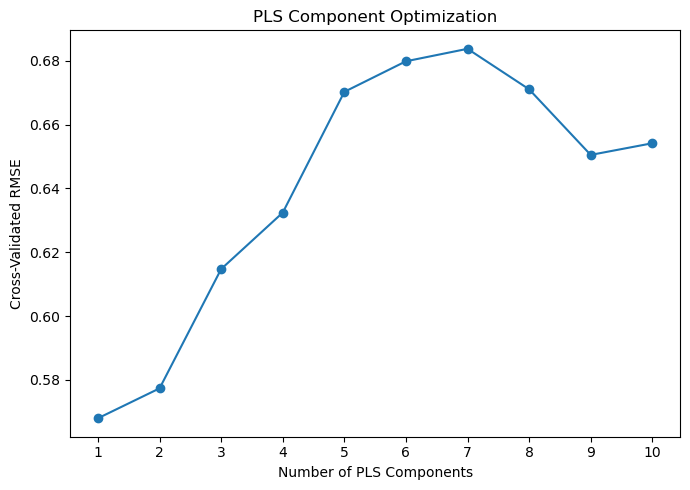

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.plot(
    pls_results_df["Components"],
    pls_results_df["CV_RMSE"],
    marker="o"
)

plt.xlabel("Number of PLS Components")
plt.ylabel("Cross-Validated RMSE")
plt.title("PLS Component Optimization")
plt.xticks(pls_results_df["Components"])
plt.tight_layout()
plt.show()

### 7.1.3 PLS Model Development

The final PLS regression model was constructed using the optimal number of latent components identified through five-fold cross-validation. The model was fitted exclusively to the training set, with descriptor standardization performed within the modeling pipeline.

In [60]:
pls_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pls", PLSRegression(n_components=optimal_components))
])

pls_model.fit(X_train_filtered, y_train)

print("PLS model fitted successfully.")
print("Optimal components:", optimal_components)

PLS model fitted successfully.
Optimal components: 1


### 7.1.4 PLS Model Performance on the Training Set

The predictive performance of the optimized PLS model was evaluated on the training set using the coefficient of determination (R²), root mean squared error (RMSE), and mean absolute error (MAE). These metrics were calculated to characterize the fitted model before independent external validation.

In [61]:
y_train_pred = pls_model.predict(X_train_filtered).ravel()

train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)

print("PLS training-set performance")
print(f"R²   : {train_r2:.4f}")
print(f"RMSE : {train_rmse:.4f}")
print(f"MAE  : {train_mae:.4f}")

PLS training-set performance
R²   : 0.5933
RMSE : 0.4261
MAE  : 0.3189


### 7.1.5 External Validation of the PLS Model

The optimized PLS model was subsequently evaluated against the independent external test set containing seven compounds. The external test compounds were not used during descriptor filtering, component optimization, or model fitting. External predictive performance was assessed using R², RMSE, and MAE.

In [62]:
y_test_pred = pls_model.predict(X_test_filtered).ravel()

test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)

print("PLS external-test performance")
print(f"External R²   : {test_r2:.4f}")
print(f"External RMSE : {test_rmse:.4f}")
print(f"External MAE  : {test_mae:.4f}")

PLS external-test performance
External R²   : 0.2716
External RMSE : 0.5082
External MAE  : 0.3803


#### 7.1.5.1 Experimental versus Predicted pIC50

Experimental and predicted pIC50 values were compared to visualize the predictive behavior of the optimized PLS model for both the training and external test sets.

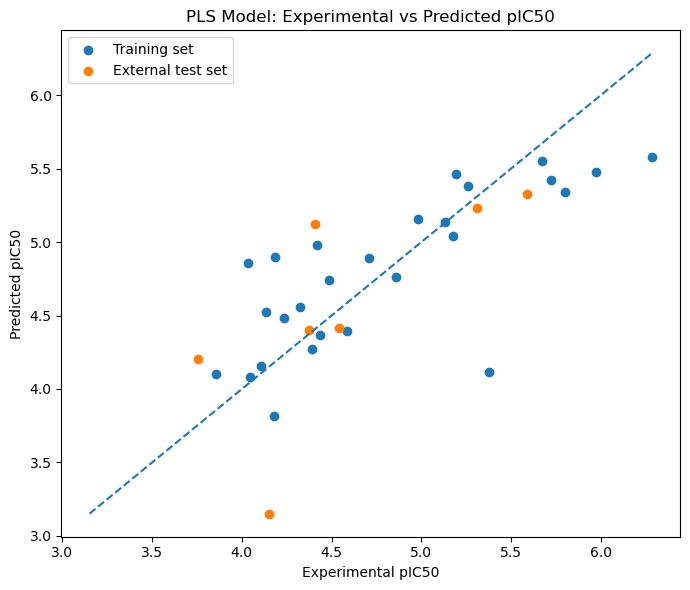

In [63]:
plt.figure(figsize=(7, 6))

plt.scatter(y_train, y_train_pred, label="Training set")
plt.scatter(y_test, y_test_pred, label="External test set")

min_val = min(y_train.min(), y_test.min(), y_train_pred.min(), y_test_pred.min())
max_val = max(y_train.max(), y_test.max(), y_train_pred.max(), y_test_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")
plt.title("PLS Model: Experimental vs Predicted pIC50")
plt.legend()
plt.tight_layout()
plt.show()

## 7.2 LASSO Regression

LASSO (Least Absolute Shrinkage and Selection Operator) regression was employed as a regularized linear modeling approach for simultaneous prediction and descriptor selection. The L1 penalty shrinks regression coefficients toward zero and can eliminate less informative descriptors by assigning their coefficients exactly to zero. Model hyperparameter optimization was performed using cross-validation on the training set only, while the independent external test set was reserved exclusively for final model evaluation.

### 7.2.1 LASSO Model Development

LASSO regression was developed using the descriptors remaining after constant-value and high-correlation filtering. Descriptor standardization and LASSO regularization were incorporated into a modeling pipeline to ensure that preprocessing was performed consistently within the cross-validation procedure.

In [64]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

In [65]:
lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(
        cv=5,
        random_state=42,
        max_iter=100000
    ))
])

lasso_pipeline.fit(X_train_filtered, y_train)

print("LASSO model fitted successfully.")
print("Optimal alpha:", lasso_pipeline.named_steps["lasso"].alpha_)

LASSO model fitted successfully.
Optimal alpha: 0.027218591050032735


### 7.2.2 LASSO Model Performance

The predictive performance of the optimized LASSO model was evaluated on both the training and independent external test sets using R², RMSE, and MAE. The external test set was not used during model fitting or hyperparameter optimization.

In [66]:
y_train_pred_lasso = lasso_pipeline.predict(X_train_filtered)
y_test_pred_lasso = lasso_pipeline.predict(X_test_filtered)

lasso_train_r2 = r2_score(y_train, y_train_pred_lasso)
lasso_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_lasso))
lasso_train_mae = mean_absolute_error(y_train, y_train_pred_lasso)

lasso_test_r2 = r2_score(y_test, y_test_pred_lasso)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_lasso))
lasso_test_mae = mean_absolute_error(y_test, y_test_pred_lasso)

print("LASSO Training Performance")
print(f"R²   : {lasso_train_r2:.4f}")
print(f"RMSE : {lasso_train_rmse:.4f}")
print(f"MAE  : {lasso_train_mae:.4f}")

print("\nLASSO External-Test Performance")
print(f"R²   : {lasso_test_r2:.4f}")
print(f"RMSE : {lasso_test_rmse:.4f}")
print(f"MAE  : {lasso_test_mae:.4f}")

LASSO Training Performance
R²   : 0.9568
RMSE : 0.1389
MAE  : 0.1203

LASSO External-Test Performance
R²   : 0.4127
RMSE : 0.4563
MAE  : 0.4174


### 7.2.3 LASSO Descriptor Selection

The fitted LASSO model was further examined to identify descriptors with non-zero regression coefficients. Descriptors with zero coefficients were considered excluded by the L1 regularization, whereas descriptors retaining non-zero coefficients were considered selected features.

In [67]:
lasso_model = lasso_pipeline.named_steps["lasso"]

lasso_coefficients = pd.Series(
    lasso_model.coef_,
    index=X_train_filtered.columns
)

selected_lasso = (
    lasso_coefficients[lasso_coefficients != 0]
    .sort_values(key=abs, ascending=False)
)

print("Number of descriptors selected by LASSO:",
      len(selected_lasso))

print("\nSelected LASSO descriptors:")
display(selected_lasso.to_frame("Coefficient"))

Number of descriptors selected by LASSO: 13

Selected LASSO descriptors:


,Coefficient
PEOE_VSA5,0.204752
SMR_VSA1,-0.175437
PEOE_VSA13,0.174430
PEOE_VSA12,-0.174114
fr_ester,-0.173172
FpDensityMorgan1,0.162603
fr_aryl_methyl,-0.075105
NumAliphaticHeterocycles,0.064617
EState_VSA5,0.036048
EState_VSA8,0.035228


## 7.3 Elastic Net Regression

Elastic Net regression was employed as a regularized linear modeling approach combining the L1 penalty of LASSO regression with the L2 penalty of ridge regression. This approach can retain groups of correlated descriptors while simultaneously controlling model complexity. The regularization parameters were optimized using five-fold cross-validation on the training set only.

### 7.3.1 Elastic Net Model Development

Elastic Net regression was developed using the 75 descriptors remaining after constant-value and high-correlation filtering. Descriptor standardization was incorporated into the modeling pipeline to ensure that scaling was performed consistently within the model-development procedure.

In [68]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV

elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        cv=5,
        random_state=42,
        max_iter=100000
    ))
])

elastic_pipeline.fit(X_train_filtered, y_train)

elastic_model = elastic_pipeline.named_steps["elastic"]

print("Elastic Net model fitted successfully.")
print("Optimal alpha:", elastic_model.alpha_)
print("Optimal l1_ratio:", elastic_model.l1_ratio_)

Elastic Net model fitted successfully.
Optimal alpha: 0.25384149110706183
Optimal l1_ratio: 0.1


### 7.3.2 Elastic Net Model Performance

The predictive performance of the optimized Elastic Net model was assessed using the training and independent external test sets. R², RMSE, and MAE were calculated to quantify the agreement between experimental and predicted pIC50 values.

In [69]:
y_train_pred_en = elastic_pipeline.predict(X_train_filtered)
y_test_pred_en = elastic_pipeline.predict(X_test_filtered)

en_train_r2 = r2_score(y_train, y_train_pred_en)
en_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_en))
en_train_mae = mean_absolute_error(y_train, y_train_pred_en)

en_test_r2 = r2_score(y_test, y_test_pred_en)
en_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_en))
en_test_mae = mean_absolute_error(y_test, y_test_pred_en)

print("Elastic Net Training Performance")
print(f"R²   : {en_train_r2:.4f}")
print(f"RMSE : {en_train_rmse:.4f}")
print(f"MAE  : {en_train_mae:.4f}")

print("\nElastic Net External-Test Performance")
print(f"R²   : {en_test_r2:.4f}")
print(f"RMSE : {en_test_rmse:.4f}")
print(f"MAE  : {en_test_mae:.4f}")

Elastic Net Training Performance
R²   : 0.9257
RMSE : 0.1821
MAE  : 0.1633

Elastic Net External-Test Performance
R²   : 0.5359
RMSE : 0.4057
MAE  : 0.3692


### 7.3.3 Elastic Net Descriptor Selection

The regression coefficients of the optimized Elastic Net model were examined to identify descriptors retained by the regularized model. Descriptors with non-zero coefficients were considered selected features, while zero-coefficient descriptors were excluded.

In [70]:
elastic_coefficients = pd.Series(
    elastic_model.coef_,
    index=X_train_filtered.columns
)

selected_elastic = (
    elastic_coefficients[elastic_coefficients != 0]
    .sort_values(key=abs, ascending=False)
)

print("Number of descriptors selected by Elastic Net:",
      len(selected_elastic))

print("\nSelected Elastic Net descriptors:")
display(selected_elastic.to_frame("Coefficient"))

Number of descriptors selected by Elastic Net: 27

Selected Elastic Net descriptors:


,Coefficient
PEOE_VSA5,0.136072
PEOE_VSA13,0.126440
fr_ester,-0.108001
FpDensityMorgan1,0.105538
PEOE_VSA12,-0.096696
NumAliphaticHeterocycles,0.081327
SMR_VSA1,-0.079979
fr_aryl_methyl,-0.075285
VSA_EState1,-0.061586
PEOE_VSA7,-0.048856


## 7.4 Comparative Evaluation of QSAR and Machine Learning Models

The predictive performance of the developed QSAR and machine learning models was compared using five-fold cross-validation on the training set. The models were evaluated using the coefficient of determination (R²), root mean square error (RMSE), and mean absolute error (MAE). All model comparisons were performed using the same training descriptor matrix to ensure a consistent and unbiased evaluation.

### 7.4.1 Cross-Validated Model Performance

The cross-validated performance of PLS, LASSO, Elastic Net, Random Forest, support vector regression (SVR), and gradient boosting models was evaluated using identical five-fold cross-validation conditions. R², RMSE, and MAE were used as complementary measures of predictive performance.

In [71]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LassoCV

lasso_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(
        cv=5,
        random_state=42,
        max_iter=100000
    ))
])

lasso_pipeline.fit(X_train_filtered, y_train)

lasso_model = lasso_pipeline.named_steps["lasso"]

print("LASSO model fitted successfully.")
print("Optimal alpha:", lasso_model.alpha_)

LASSO model fitted successfully.
Optimal alpha: 0.027218591050032735


In [72]:
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

lasso_cv_pred = cross_val_predict(
    lasso_pipeline,
    X_train_filtered,
    y_train,
    cv=cv
)

lasso_cv_r2 = r2_score(y_train, lasso_cv_pred)
lasso_cv_rmse = np.sqrt(mean_squared_error(y_train, lasso_cv_pred))
lasso_cv_mae = mean_absolute_error(y_train, lasso_cv_pred)

print("LASSO 5-fold CV")
print(f"R²   : {lasso_cv_r2:.4f}")
print(f"RMSE : {lasso_cv_rmse:.4f}")
print(f"MAE  : {lasso_cv_mae:.4f}")

LASSO 5-fold CV
R²   : 0.2766
RMSE : 0.5683
MAE  : 0.4493


In [73]:
from sklearn.linear_model import ElasticNetCV

elastic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        cv=5,
        random_state=42,
        max_iter=100000
    ))
])

elastic_pipeline.fit(X_train_filtered, y_train)

elastic_model = elastic_pipeline.named_steps["elastic"]

print("Elastic Net model fitted successfully.")
print("Optimal alpha:", elastic_model.alpha_)
print("Optimal l1 ratio:", elastic_model.l1_ratio_)

Elastic Net model fitted successfully.
Optimal alpha: 0.25384149110706183
Optimal l1 ratio: 0.1


In [74]:
elastic_cv_pred = cross_val_predict(
    elastic_pipeline,
    X_train_filtered,
    y_train,
    cv=cv
)

elastic_cv_r2 = r2_score(y_train, elastic_cv_pred)
elastic_cv_rmse = np.sqrt(mean_squared_error(y_train, elastic_cv_pred))
elastic_cv_mae = mean_absolute_error(y_train, elastic_cv_pred)

print("Elastic Net 5-fold CV")
print(f"R²   : {elastic_cv_r2:.4f}")
print(f"RMSE : {elastic_cv_rmse:.4f}")
print(f"MAE  : {elastic_cv_mae:.4f}")

Elastic Net 5-fold CV
R²   : 0.2255
RMSE : 0.5880
MAE  : 0.4730


In [75]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# Five-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Use the same 75-descriptor training matrix
max_components = min(
    10,
    X_train_filtered.shape[1],
    X_train_filtered.shape[0] - 1
)

pls_results = []

for n_comp in range(1, max_components + 1):

    pls_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(n_components=n_comp))
    ])

    pls_cv_pred = cross_val_predict(
        pls_pipeline,
        X_train_filtered,
        y_train,
        cv=cv
    ).ravel()

    r2 = r2_score(y_train, pls_cv_pred)
    rmse = np.sqrt(mean_squared_error(y_train, pls_cv_pred))
    mae = mean_absolute_error(y_train, pls_cv_pred)

    pls_results.append({
        "Components": n_comp,
        "CV_R2_Q2": r2,
        "CV_RMSE": rmse,
        "CV_MAE": mae
    })

pls_results_df = pd.DataFrame(pls_results)

display(pls_results_df)

,Components,CV_R2_Q2,CV_RMSE,CV_MAE
0,1,0.277308,0.567985,0.437798
1,2,0.253257,0.577359,0.440437
2,3,0.153419,0.614744,0.487260
3,4,0.104025,0.632423,0.487914
4,5,-0.006415,0.670268,0.519138
5,6,-0.035384,0.679846,0.518052
6,7,-0.047323,0.683755,0.515692
7,8,-0.008807,0.671064,0.509217
8,9,0.052061,0.650504,0.505260
9,10,0.041384,0.654157,0.504570


In [76]:
optimal_components = int(
    pls_results_df.loc[
        pls_results_df["CV_RMSE"].idxmin(),
        "Components"
    ]
)

print("Optimal PLS components:", optimal_components)

Optimal PLS components: 1


In [77]:
pls_final_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pls", PLSRegression(
        n_components=optimal_components
    ))
])

pls_cv_pred = cross_val_predict(
    pls_final_pipeline,
    X_train_filtered,
    y_train,
    cv=cv
).ravel()

pls_cv_r2 = r2_score(y_train, pls_cv_pred)
pls_cv_rmse = np.sqrt(
    mean_squared_error(y_train, pls_cv_pred)
)
pls_cv_mae = mean_absolute_error(
    y_train,
    pls_cv_pred
)

print("PLS 5-fold CV")
print(f"R² / Q² : {pls_cv_r2:.4f}")
print(f"RMSE    : {pls_cv_rmse:.4f}")
print(f"MAE     : {pls_cv_mae:.4f}")

PLS 5-fold CV
R² / Q² : 0.2773
RMSE    : 0.5680
MAE     : 0.4378


In [78]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

rf = RandomForestRegressor(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42
)

rf_pred_cv = cross_val_predict(
    rf,
    X_train_filtered,
    y_train,
    cv=cv
)

rf_cv_r2 = r2_score(y_train, rf_pred_cv)
rf_cv_rmse = np.sqrt(
    mean_squared_error(y_train, rf_pred_cv)
)
rf_cv_mae = mean_absolute_error(
    y_train,
    rf_pred_cv
)

print("Random Forest 5-fold CV")
print(f"R² / Q² : {rf_cv_r2:.4f}")
print(f"RMSE    : {rf_cv_rmse:.4f}")
print(f"MAE     : {rf_cv_mae:.4f}")

Random Forest 5-fold CV
R² / Q² : 0.3171
RMSE    : 0.5521
MAE     : 0.4164


In [79]:
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

svr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        gamma="scale",
        epsilon=0.1
    ))
])

svr_pred_cv = cross_val_predict(
    svr_model,
    X_train_filtered,
    y_train,
    cv=cv
)

svr_cv_r2 = r2_score(y_train, svr_pred_cv)
svr_cv_rmse = np.sqrt(
    mean_squared_error(y_train, svr_pred_cv)
)
svr_cv_mae = mean_absolute_error(
    y_train,
    svr_pred_cv
)

print("SVR 5-fold CV")
print(f"R² / Q² : {svr_cv_r2:.4f}")
print(f"RMSE    : {svr_cv_rmse:.4f}")
print(f"MAE     : {svr_cv_mae:.4f}")

SVR 5-fold CV
R² / Q² : 0.2908
RMSE    : 0.5626
MAE     : 0.4542


In [80]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

gb_pred_cv = cross_val_predict(
    gb_model,
    X_train_filtered,
    y_train,
    cv=cv
)

gb_cv_r2 = r2_score(y_train, gb_pred_cv)

gb_cv_rmse = np.sqrt(
    mean_squared_error(y_train, gb_pred_cv)
)

gb_cv_mae = mean_absolute_error(
    y_train,
    gb_pred_cv
)

print("Gradient Boosting 5-fold CV")
print(f"R² / Q² : {gb_cv_r2:.4f}")
print(f"RMSE    : {gb_cv_rmse:.4f}")
print(f"MAE     : {gb_cv_mae:.4f}")

Gradient Boosting 5-fold CV
R² / Q² : -0.1355
RMSE    : 0.7120
MAE     : 0.5048


### Comparative Assessment of Cross-Validated Model Performance

The cross-validated performance metrics of the six developed QSAR and machine-learning models were compiled and compared to identify the model providing the most reliable predictive performance. Higher cross-validated R²/Q² values and lower RMSE and MAE values were considered indicative of better predictive performance.

In [81]:
# Compile cross-validated performance of all models

cv_comparison = pd.DataFrame({
    "Model": [
        "PLS",
        "LASSO",
        "Elastic Net",
        "Random Forest",
        "SVR",
        "Gradient Boosting"
    ],
    "CV_R2_Q2": [
        pls_cv_r2,
        lasso_cv_r2,
        elastic_cv_r2,
        rf_cv_r2,
        svr_cv_r2,
        gb_cv_r2
    ],
    "CV_RMSE": [
        pls_cv_rmse,
        lasso_cv_rmse,
        elastic_cv_rmse,
        rf_cv_rmse,
        svr_cv_rmse,
        gb_cv_rmse
    ],
    "CV_MAE": [
        pls_cv_mae,
        lasso_cv_mae,
        elastic_cv_mae,
        rf_cv_mae,
        svr_cv_mae,
        gb_cv_mae
    ]
})

# Round values for presentation
cv_comparison = cv_comparison.round(4)

# Sort by CV R²/Q² (highest first)
cv_comparison = cv_comparison.sort_values(
    "CV_R2_Q2",
    ascending=False
).reset_index(drop=True)

display(cv_comparison)

,Model,CV_R2_Q2,CV_RMSE,CV_MAE
0,Random Forest,0.3171,0.5521,0.4164
1,SVR,0.2908,0.5626,0.4542
2,PLS,0.2773,0.5680,0.4378
3,LASSO,0.2766,0.5683,0.4493
4,Elastic Net,0.2255,0.5880,0.4730
5,Gradient Boosting,-0.1355,0.7120,0.5048


In [82]:
# Identify the best-performing model

best_model = cv_comparison.iloc[0]["Model"]
best_r2 = cv_comparison.iloc[0]["CV_R2_Q2"]
best_rmse = cv_comparison.iloc[0]["CV_RMSE"]
best_mae = cv_comparison.iloc[0]["CV_MAE"]

print("Best model based on cross-validation:")
print("Model:", best_model)
print("CV R² / Q²:", best_r2)
print("CV RMSE:", best_rmse)
print("CV MAE:", best_mae)

Best model based on cross-validation:
Model: Random Forest
CV R² / Q²: 0.3171
CV RMSE: 0.5521
CV MAE: 0.4164


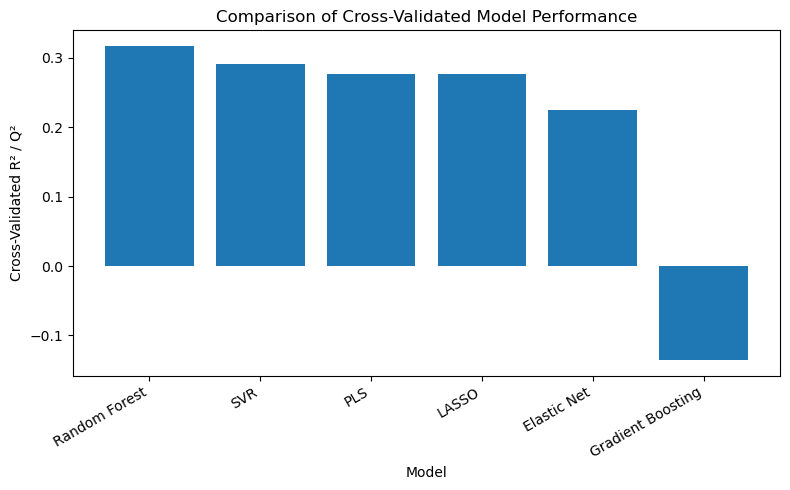

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    cv_comparison["Model"],
    cv_comparison["CV_R2_Q2"]
)

plt.xlabel("Model")
plt.ylabel("Cross-Validated R² / Q²")
plt.title("Comparison of Cross-Validated Model Performance")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

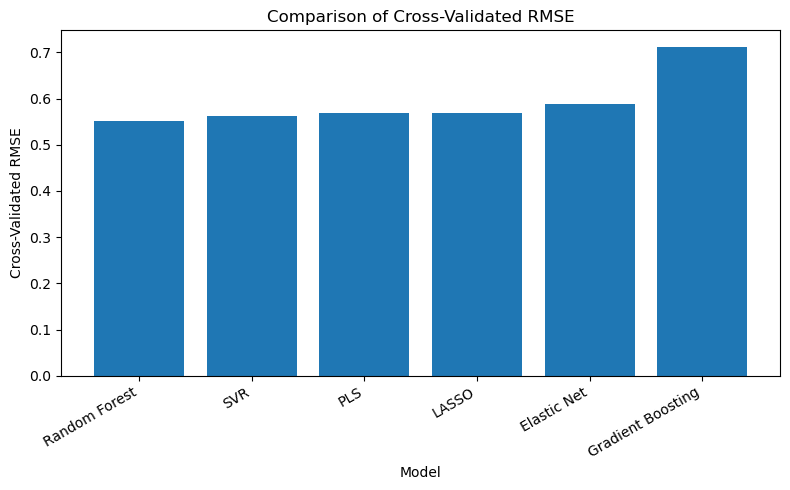

In [84]:
plt.figure(figsize=(8, 5))

plt.bar(
    cv_comparison["Model"],
    cv_comparison["CV_RMSE"]
)

plt.xlabel("Model")
plt.ylabel("Cross-Validated RMSE")
plt.title("Comparison of Cross-Validated RMSE")

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretation of Cross-Validated Model Performance

The six models exhibited different predictive performances under identical five-fold cross-validation conditions. Random Forest provided the best overall cross-validated performance, showing the highest Q² value (0.3171), together with the lowest RMSE (0.5521) and MAE (0.4164). SVR showed the second-highest Q² (0.2908), followed by PLS (0.2773) and LASSO (0.2766). Elastic Net showed comparatively lower predictive performance (Q² = 0.2255), whereas Gradient Boosting produced a negative Q² value (−0.1355) and the highest RMSE (0.7120), indicating poor predictive performance under the present dataset and model configuration.

Overall, Random Forest was identified as the best-performing model among the evaluated approaches based on the combined criteria of higher cross-validated Q² and lower RMSE and MAE. However, the relatively modest Q² values observed across the models indicate limited predictive strength, which is likely influenced by the small dataset size and should be considered when interpreting the model performance. External test-set validation was therefore used as an additional assessment of predictive applicability.

### 7.4.2 External Test-Set Validation

The predictive performance of the developed models was further assessed using an independent external test set comprising seven compounds that were not involved in model training or cross-validation. Each finalized model was refitted using the complete training set, and predictions were subsequently generated for the external test compounds. External predictive performance was evaluated using the coefficient of determination (R²), root mean square error (RMSE), and mean absolute error (MAE).

In [85]:
# ============================================================
# External Test-Set Prediction
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. PLS
# Optimal number of components = 1
# ------------------------------------------------------------

pls_final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("pls", PLSRegression(n_components=1))
])

pls_final_model.fit(X_train_filtered, y_train)

pls_test_pred = pls_final_model.predict(
    X_test_filtered
).ravel()


# ------------------------------------------------------------
# 2. LASSO
# Alpha obtained from LASSO-CV
# ------------------------------------------------------------

lasso_final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(
        alpha=lasso_model.alpha_,
        max_iter=100000
    ))
])

lasso_final_model.fit(X_train_filtered, y_train)

lasso_test_pred = lasso_final_model.predict(
    X_test_filtered
)


# ------------------------------------------------------------
# 3. Elastic Net
# Alpha and l1_ratio obtained from Elastic Net-CV
# ------------------------------------------------------------

elastic_final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("elastic", ElasticNet(
        alpha=elastic_model.alpha_,
        l1_ratio=elastic_model.l1_ratio_,
        max_iter=100000
    ))
])

elastic_final_model.fit(X_train_filtered, y_train)

elastic_test_pred = elastic_final_model.predict(
    X_test_filtered
)


# ------------------------------------------------------------
# 4. Random Forest
# ------------------------------------------------------------

rf_final_model = RandomForestRegressor(
    n_estimators=500,
    max_features="sqrt",
    min_samples_leaf=2,
    random_state=42
)

rf_final_model.fit(
    X_train_filtered,
    y_train
)

rf_test_pred = rf_final_model.predict(
    X_test_filtered
)


# ------------------------------------------------------------
# 5. SVR
# ------------------------------------------------------------

svr_final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        gamma="scale",
        epsilon=0.1
    ))
])

svr_final_model.fit(
    X_train_filtered,
    y_train
)

svr_test_pred = svr_final_model.predict(
    X_test_filtered
)


# ------------------------------------------------------------
# 6. Gradient Boosting
# ------------------------------------------------------------

gb_final_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

gb_final_model.fit(
    X_train_filtered,
    y_train
)

gb_test_pred = gb_final_model.predict(
    X_test_filtered
)


print("External test-set predictions generated successfully.")
print("Number of external test compounds:", len(y_test))

External test-set predictions generated successfully.
Number of external test compounds: 7


In [86]:
# ============================================================
# External Test-Set Performance
# ============================================================

def calculate_test_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    return r2, rmse, mae


test_results = []

models_and_predictions = {
    "PLS": pls_test_pred,
    "LASSO": lasso_test_pred,
    "Elastic Net": elastic_test_pred,
    "Random Forest": rf_test_pred,
    "SVR": svr_test_pred,
    "Gradient Boosting": gb_test_pred
}

for model_name, predictions in models_and_predictions.items():
    
    r2, rmse, mae = calculate_test_metrics(
        y_test,
        predictions
    )
    
    test_results.append({
        "Model": model_name,
        "External_R2": r2,
        "External_RMSE": rmse,
        "External_MAE": mae
    })


external_comparison = pd.DataFrame(test_results)

external_comparison = external_comparison.round(4)

display(external_comparison)

,Model,External_R2,External_RMSE,External_MAE
0,PLS,0.2716,0.5082,0.3803
1,LASSO,0.4127,0.4563,0.4174
2,Elastic Net,0.5359,0.4057,0.3692
3,Random Forest,0.4418,0.4449,0.3367
4,SVR,0.6361,0.3592,0.2976
5,Gradient Boosting,0.2343,0.5211,0.3883


In [87]:
# ============================================================
# External Test-Set Observed vs Predicted Values
# ============================================================

external_predictions = pd.DataFrame({
    "Observed_pIC50": y_test.values,
    "PLS_Predicted": pls_test_pred,
    "LASSO_Predicted": lasso_test_pred,
    "ElasticNet_Predicted": elastic_test_pred,
    "RandomForest_Predicted": rf_test_pred,
    "SVR_Predicted": svr_test_pred,
    "GradientBoosting_Predicted": gb_test_pred
})

display(external_predictions.round(4))

,Observed_pIC50,PLS_Predicted,LASSO_Predicted,ElasticNet_Predicted,RandomForest_Predicted,SVR_Predicted,GradientBoosting_Predicted
0,3.7540,4.2074,4.1219,4.2870,4.4398,4.2301,4.4496
1,5.5884,5.3291,5.8711,5.7439,4.8987,5.2617,4.7603
2,4.5436,4.4162,3.8207,4.0217,4.4637,4.4694,4.4586
3,4.3737,4.4047,3.8501,4.0153,4.4054,4.4522,4.5067
4,5.3072,5.2310,4.9432,5.0965,5.2845,5.2016,5.3265
5,4.4089,5.1213,4.5217,4.6180,5.0230,4.8088,5.2394
6,4.1537,3.1513,3.6056,3.5581,4.3869,4.7759,4.2807


### External Test-Set Observed versus Predicted pIC50

The observed and predicted pIC50 values obtained from the independent external test set were compared for the models evaluated. The observed-versus-predicted relationship was examined relative to the ideal 1:1 prediction line to visualize the external predictive performance.

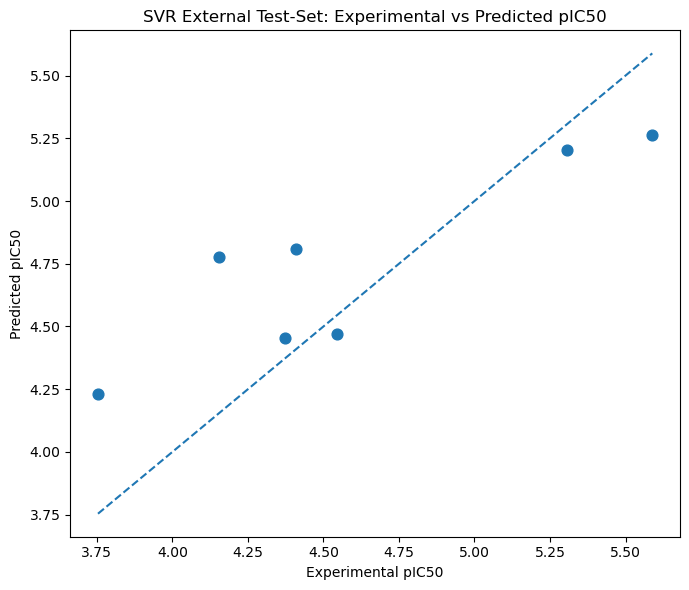

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    svr_test_pred,
    s=60
)

# Ideal prediction line
min_val = min(
    y_test.min(),
    svr_test_pred.min()
)

max_val = max(
    y_test.max(),
    svr_test_pred.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.xlabel("Experimental pIC50")
plt.ylabel("Predicted pIC50")
plt.title("SVR External Test-Set: Experimental vs Predicted pIC50")

plt.tight_layout()
plt.show()

In [89]:
external_svr_table = pd.DataFrame({
    "ID": test_df["ID"].values,
    "Observed_pIC50": y_test.values,
    "Predicted_pIC50": svr_test_pred
})

external_svr_table["Residual"] = (
    external_svr_table["Observed_pIC50"]
    - external_svr_table["Predicted_pIC50"]
)

external_svr_table["Absolute_Error"] = (
    external_svr_table["Residual"].abs()
)

display(external_svr_table.round(4))

,ID,Observed_pIC50,Predicted_pIC50,Residual,Absolute_Error
0,20,3.7540,4.2301,-0.4761,0.4761
1,2,5.5884,5.2617,0.3267,0.3267
2,33,4.5436,4.4694,0.0742,0.0742
3,32,4.3737,4.4522,-0.0785,0.0785
4,10,5.3072,5.2016,0.1056,0.1056
5,27,4.4089,4.8088,-0.3999,0.3999
6,18,4.1537,4.7759,-0.6222,0.6222


In [90]:
print("SVR External Test-Set Validation")
print("----------------------------------")

print(f"R²   : {r2_score(y_test, svr_test_pred):.4f}")
print(
    f"RMSE : "
    f"{np.sqrt(mean_squared_error(y_test, svr_test_pred)):.4f}"
)
print(
    f"MAE  : "
    f"{mean_absolute_error(y_test, svr_test_pred):.4f}"
)

print(
    f"Maximum absolute error : "
    f"{external_svr_table['Absolute_Error'].max():.4f}"
)

print(
    f"Mean absolute error    : "
    f"{external_svr_table['Absolute_Error'].mean():.4f}"
)

SVR External Test-Set Validation
----------------------------------
R²   : 0.6361
RMSE : 0.3592
MAE  : 0.2976
Maximum absolute error : 0.6222
Mean absolute error    : 0.2976


### Interpretation of External Test-Set Performance

External validation demonstrated differences in predictive performance among the evaluated models. SVR showed the strongest performance on the independent test set, with an external R² of 0.6361, RMSE of 0.3592, and MAE of 0.2976. Elastic Net showed the second-highest external R² (0.5359), whereas Random Forest achieved an external R² of 0.4418. PLS, LASSO, and Gradient Boosting showed comparatively lower external predictive performance.

Although Random Forest provided the best five-fold cross-validated performance on the training set, SVR exhibited the highest predictive accuracy for the independent external compounds. This difference highlights the variability associated with model performance on a small dataset. Importantly, the external test set was not used for model fitting or model selection and was therefore retained as an independent assessment of predictive applicability.

### 7.4.3 Comparative Cross-Validation and External-Test Performance

The cross-validated and external-test-set performances of the developed models were compared using R²/Q², RMSE, and MAE. Cross-validation was used to assess model robustness within the training dataset, whereas the independent external test set was used to evaluate predictive applicability toward unseen compounds. The two assessments were considered complementary rather than interchangeable, particularly given the limited number of compounds in the external test set.

In [91]:
# ============================================================
# Combined Cross-Validation and External-Test Performance
# ============================================================

combined_results = pd.DataFrame({
    "Model": [
        "PLS",
        "LASSO",
        "Elastic Net",
        "Random Forest",
        "SVR",
        "Gradient Boosting"
    ],

    "CV_R2_Q2": [
        pls_cv_r2,
        lasso_cv_r2,
        elastic_cv_r2,
        rf_cv_r2,
        svr_cv_r2,
        gb_cv_r2
    ],

    "CV_RMSE": [
        pls_cv_rmse,
        lasso_cv_rmse,
        elastic_cv_rmse,
        rf_cv_rmse,
        svr_cv_rmse,
        gb_cv_rmse
    ],

    "CV_MAE": [
        pls_cv_mae,
        lasso_cv_mae,
        elastic_cv_mae,
        rf_cv_mae,
        svr_cv_mae,
        gb_cv_mae
    ],

    "External_R2": [
        external_comparison.loc[
            external_comparison["Model"] == "PLS",
            "External_R2"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "LASSO",
            "External_R2"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "Elastic Net",
            "External_R2"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "Random Forest",
            "External_R2"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "SVR",
            "External_R2"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "Gradient Boosting",
            "External_R2"
        ].values[0]
    ],

    "External_RMSE": [
        external_comparison.loc[
            external_comparison["Model"] == "PLS",
            "External_RMSE"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "LASSO",
            "External_RMSE"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "Elastic Net",
            "External_RMSE"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "Random Forest",
            "External_RMSE"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "SVR",
            "External_RMSE"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "Gradient Boosting",
            "External_RMSE"
        ].values[0]
    ],

    "External_MAE": [
        external_comparison.loc[
            external_comparison["Model"] == "PLS",
            "External_MAE"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "LASSO",
            "External_MAE"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "Elastic Net",
            "External_MAE"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "Random Forest",
            "External_MAE"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "SVR",
            "External_MAE"
        ].values[0],

        external_comparison.loc[
            external_comparison["Model"] == "Gradient Boosting",
            "External_MAE"
        ].values[0]
    ]
})

combined_results = combined_results.round(4)

display(combined_results)

,Model,CV_R2_Q2,CV_RMSE,CV_MAE,External_R2,External_RMSE,External_MAE
0,PLS,0.2773,0.5680,0.4378,0.2716,0.5082,0.3803
1,LASSO,0.2766,0.5683,0.4493,0.4127,0.4563,0.4174
2,Elastic Net,0.2255,0.5880,0.4730,0.5359,0.4057,0.3692
3,Random Forest,0.3171,0.5521,0.4164,0.4418,0.4449,0.3367
4,SVR,0.2908,0.5626,0.4542,0.6361,0.3592,0.2976
5,Gradient Boosting,-0.1355,0.7120,0.5048,0.2343,0.5211,0.3883


In [92]:
combined_results.to_excel(
    "QSAR_CV_External_Model_Comparison.xlsx",
    index=False
)

print("Combined model comparison saved successfully.")

Combined model comparison saved successfully.


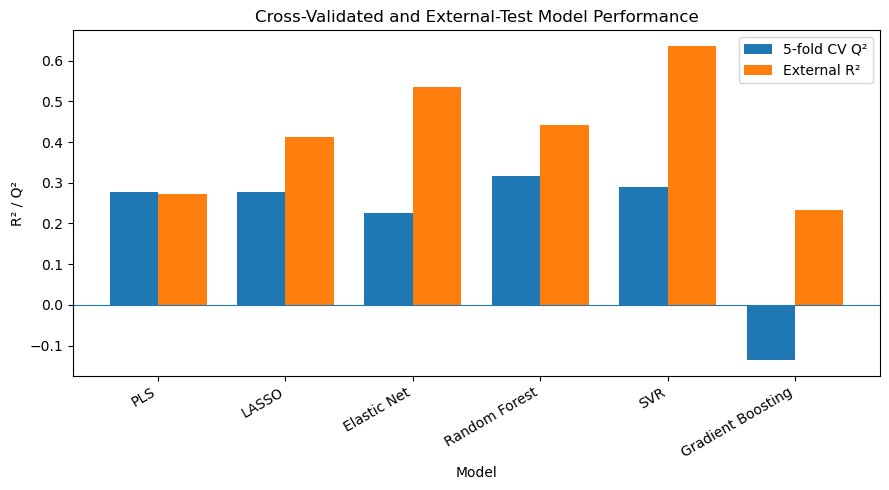

In [93]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(combined_results["Model"]))
width = 0.38

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    combined_results["CV_R2_Q2"],
    width,
    label="5-fold CV Q²"
)

plt.bar(
    x + width/2,
    combined_results["External_R2"],
    width,
    label="External R²"
)

plt.axhline(0, linestyle="-", linewidth=0.8)

plt.xlabel("Model")
plt.ylabel("R² / Q²")
plt.title("Cross-Validated and External-Test Model Performance")

plt.xticks(
    x,
    combined_results["Model"],
    rotation=30,
    ha="right"
)

plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of Comparative Model Performance

Comparison of cross-validated and external-test performance revealed differences in the relative performance of the models. Random Forest showed the highest cross-validated Q² (0.3171), with the lowest CV RMSE (0.5521) and CV MAE (0.4164), indicating the strongest performance during internal validation. In contrast, SVR showed the highest external-test R² (0.6361), together with the lowest external RMSE (0.3592) and MAE (0.2976), demonstrating the strongest predictive performance for the independent test compounds.

The difference between the internally cross-validated and externally validated rankings indicates that model performance was sensitive to the composition of the small dataset. Therefore, no single metric was considered independently sufficient for model assessment. The combined evaluation using five-fold cross-validation and independent external validation provides a more comprehensive assessment of predictive performance. Although Random Forest showed the best internal cross-validation performance, SVR demonstrated superior prediction of the independent external compounds, suggesting better generalization to the present external test set.

## 7.5 Model Interpretation and Descriptor–Activity Relationship

The selected descriptors were further examined to obtain insights into the molecular features associated with the observed pIC50 values. Descriptor interpretation was primarily based on the optimized LASSO model because LASSO simultaneously performs regularization and feature selection by retaining descriptors with non-zero regression coefficients. The magnitude of each coefficient reflects its relative contribution to the predicted response within the fitted model, whereas the sign indicates the direction of the association with pIC50. Positive coefficients indicate that increasing the corresponding descriptor is associated with an increase in predicted pIC50, whereas negative coefficients indicate an inverse association, while keeping the other descriptors constant.

### 7.5.1 LASSO Descriptor Coefficients

The non-zero regression coefficients obtained from the optimized LASSO model were examined to identify the molecular descriptors contributing to pIC50 prediction. The selected descriptors were ranked according to the absolute magnitude of their standardized regression coefficients to facilitate comparison of their relative contributions.

In [94]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Extract the fitted LASSO model
lasso_model = lasso_pipeline.named_steps["lasso"]

# Create coefficient series using the filtered training descriptors
lasso_coefficients = pd.Series(
    lasso_model.coef_,
    index=X_train_filtered.columns
)

# Retain non-zero coefficients
selected_lasso = (
    lasso_coefficients[lasso_coefficients != 0]
    .sort_values(key=np.abs, ascending=False)
)

print("Number of descriptors selected by LASSO:",
      len(selected_lasso))

print("\nSelected LASSO descriptors:")
display(selected_lasso.to_frame("Coefficient"))

Number of descriptors selected by LASSO: 13

Selected LASSO descriptors:


,Coefficient
PEOE_VSA5,0.204752
SMR_VSA1,-0.175437
PEOE_VSA13,0.174430
PEOE_VSA12,-0.174114
fr_ester,-0.173172
FpDensityMorgan1,0.162603
fr_aryl_methyl,-0.075105
NumAliphaticHeterocycles,0.064617
EState_VSA5,0.036048
EState_VSA8,0.035228


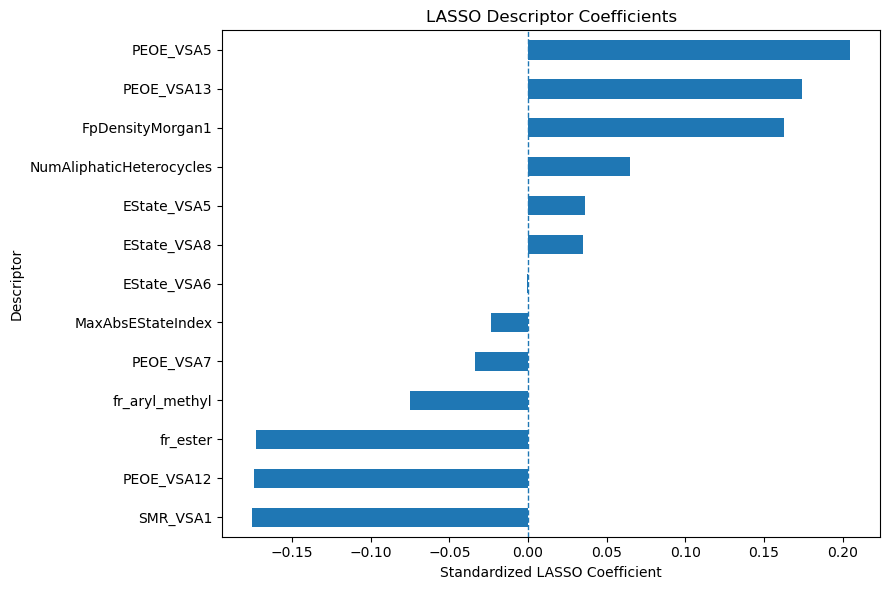

In [95]:
# Plot LASSO descriptor coefficients

plt.figure(figsize=(9, 6))

selected_lasso.sort_values().plot(
    kind="barh"
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Standardized LASSO Coefficient")
plt.ylabel("Descriptor")
plt.title("LASSO Descriptor Coefficients")

plt.tight_layout()
plt.show()

### 7.5.2 Interpretation of Descriptor Contributions

The LASSO model retained 13 descriptors with non-zero regression coefficients, indicating that these molecular features contributed to the prediction of pIC50 within the developed model. Among the selected descriptors, PEOE_VSA5, PEOE_VSA13, PEOE_VSA12, SMR_VSA1, fr_ester, and FpDensityMorgan1 exhibited comparatively larger absolute coefficients and therefore represented the dominant contributors within the regularized linear model.

Positive coefficients were observed for descriptors such as PEOE_VSA5, PEOE_VSA13, FpDensityMorgan1, and NumAliphaticHeterocycles, suggesting a positive association between these molecular characteristics and predicted pIC50 values. In contrast, SMR_VSA1, PEOE_VSA12, fr_ester, and fr_aryl_methyl showed negative coefficients, indicating an inverse association with predicted pIC50 within the fitted model.

The selected descriptors represent different aspects of molecular structure, including surface-area-related properties, molecular refractivity, functional-group composition, heterocyclic features, and molecular fingerprint density. The coexistence of positive and negative contributions suggests that the biological activity of the investigated compounds is influenced by multiple structural and physicochemical characteristics rather than by a single molecular descriptor.

## 7.6 Applicability Domain Analysis

The applicability domain (AD) analysis was performed to assess the reliability of the developed QSAR model for individual compounds. The AD defines the chemical and response space within which the model can be expected to provide reliable predictions. A leverage-based approach was employed using a Williams plot, in which leverage values were plotted against standardized residuals. Compounds exhibiting unusually high leverage were considered structurally influential, whereas compounds with large standardized residuals were examined as potential response outliers.

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Fit final LASSO model on the training dataset
# ---------------------------------------------------------

lasso_model = lasso_pipeline.named_steps["lasso"]

# Selected non-zero descriptors
selected_descriptors = X_train_filtered.columns[
    lasso_model.coef_ != 0
]

print("Number of selected descriptors:",
      len(selected_descriptors))

print("\nSelected descriptors:")
print(list(selected_descriptors))


# ---------------------------------------------------------
# 2. Prepare selected descriptor matrix
# ---------------------------------------------------------

X_lasso = X_train_filtered[selected_descriptors].copy()

# Standardize descriptors in the same way used by the model
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_lasso)


# ---------------------------------------------------------
# 3. Calculate leverage values
# ---------------------------------------------------------

X_design = np.column_stack([
    np.ones(X_scaled.shape[0]),
    X_scaled
])

# Hat matrix
H = X_design @ np.linalg.pinv(
    X_design.T @ X_design
) @ X_design.T

leverage = np.diag(H)


# ---------------------------------------------------------
# 4. Calculate model predictions and residuals
# ---------------------------------------------------------

y_pred_lasso = lasso_pipeline.predict(
    X_train_filtered
)

residuals = y_train.values - y_pred_lasso


# ---------------------------------------------------------
# 5. Standardized residuals
# ---------------------------------------------------------

residual_std = np.std(residuals, ddof=1)

standardized_residuals = residuals / residual_std


# ---------------------------------------------------------
# 6. Critical leverage
# ---------------------------------------------------------

n = X_scaled.shape[0]
p = X_scaled.shape[1]

h_star = 3 * (p + 1) / n

print("\nNumber of compounds:", n)
print("Number of descriptors:", p)
print("Critical leverage (h*):", h_star)

Number of selected descriptors: 13

Selected descriptors:
['MaxAbsEStateIndex', 'FpDensityMorgan1', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA5', 'PEOE_VSA7', 'SMR_VSA1', 'EState_VSA5', 'EState_VSA6', 'EState_VSA8', 'NumAliphaticHeterocycles', 'fr_aryl_methyl', 'fr_ester']

Number of compounds: 27
Number of descriptors: 13
Critical leverage (h*): 1.5555555555555556


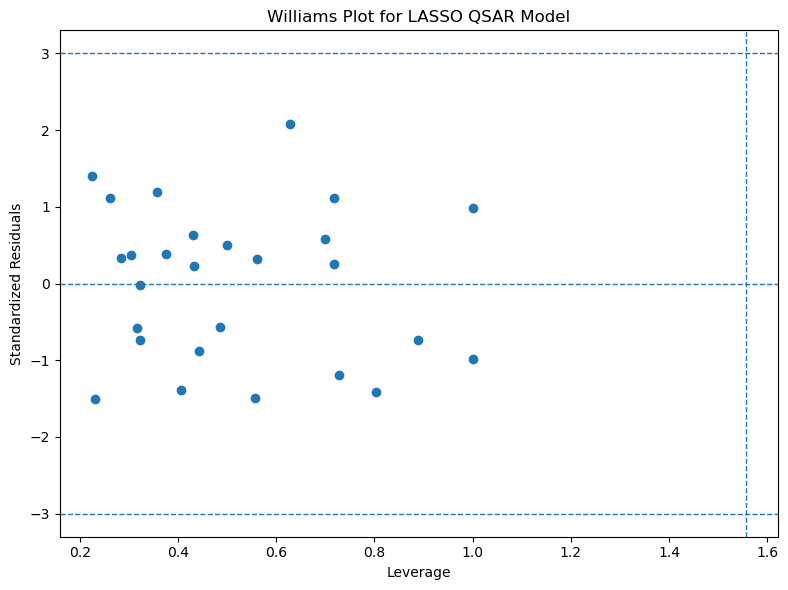

In [97]:
plt.figure(figsize=(8, 6))

plt.scatter(
    leverage,
    standardized_residuals
)

# Zero residual line
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

# ±3 standardized residual limits
plt.axhline(
    y=3,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    y=-3,
    linestyle="--",
    linewidth=1
)

# Critical leverage
plt.axvline(
    x=h_star,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Leverage")
plt.ylabel("Standardized Residuals")
plt.title("Williams Plot for LASSO QSAR Model")

plt.tight_layout()
plt.show()

In [98]:
ad_table = pd.DataFrame({
    "Compound": train_df["Compound"].values,
    "Observed_pIC50": y_train.values,
    "Predicted_pIC50": y_pred_lasso,
    "Residual": residuals,
    "Standardized_Residual": standardized_residuals,
    "Leverage": leverage
})

ad_table["AD_Status"] = np.where(
    (ad_table["Leverage"] <= h_star) &
    (np.abs(ad_table["Standardized_Residual"]) <= 3),
    "Inside AD",
    "Outside AD"
)

display(ad_table.round(4))

,Compound,Observed_pIC50,Predicted_pIC50,Residual,Standardized_Residual,Leverage,AD_Status
0,K17,5.3768,5.2380,0.1388,0.9803,1.0000,Inside AD
1,K30,4.4855,4.5656,-0.0801,-0.5658,0.4865,Inside AD
2,K5,5.1314,5.0773,0.0541,0.3822,0.3761,Inside AD
3,K29,4.1871,4.3836,-0.1965,-1.3882,0.4071,Inside AD
4,K11,4.9834,4.9387,0.0447,0.3157,0.5614,Inside AD
5,K28,4.4342,4.5383,-0.1041,-0.7353,0.8891,Inside AD
6,K15,4.1805,3.9824,0.1981,1.3997,0.2258,Inside AD
7,K9,5.7986,5.6292,0.1694,1.1967,0.3575,Inside AD
8,K34,4.3233,4.2336,0.0897,0.6337,0.4304,Inside AD
9,K13,4.0453,4.2139,-0.1686,-1.1909,0.7275,Inside AD


In [99]:
print(
    ad_table["AD_Status"].value_counts()
)

AD_Status
Inside AD    27
Name: count, dtype: int64


### 7.6.2 Interpretation of Applicability Domain

The applicability domain of the LASSO-based QSAR model was evaluated using a leverage-based Williams plot. The analysis was performed using the 13 descriptors retained by LASSO and 27 training compounds. The critical leverage threshold was calculated as h* = 3(p + 1)/n, where p represents the number of selected descriptors and n represents the number of training compounds. The resulting critical leverage was approximately 1.556.

All 27 training compounds were located within the predefined applicability domain, with standardized residuals ranging from approximately −1.51 to +2.07. None of the compounds exhibited an absolute standardized residual greater than 3, indicating the absence of apparent response outliers according to the adopted criterion. Although K17 and K22 exhibited a leverage value of 1.0000, their standardized residuals remained within the ±3 limits.

It should be noted that the calculated critical leverage threshold (h* = 1.556) exceeds the theoretical maximum leverage value of 1.0. This is a consequence of the relatively small number of training compounds compared with the number of descriptors retained by the LASSO model. Therefore, the leverage criterion has limited discriminatory power for identifying influential compounds in the present dataset. Accordingly, the applicability-domain results should be interpreted cautiously and in conjunction with the standardized residual analysis and independent external validation.

Overall, the Williams plot did not identify any training compound with an extreme standardized residual or an observation exceeding the adopted leverage threshold. The analysis therefore provides no evidence of pronounced response outliers within the training set, although the small sample size and relatively high descriptor-to-compound ratio represent important limitations of the present applicability-domain assessment.

In [100]:
# ============================================================
# External Test-Set Applicability Domain
# ============================================================

# Use the same 13 LASSO-selected descriptors
X_train_lasso = X_train_filtered[selected_descriptors].copy()
X_test_lasso = X_test[selected_descriptors].copy()

# Use the SAME scaler fitted on the training set
scaler_ad = StandardScaler()

X_train_scaled = scaler_ad.fit_transform(X_train_lasso)
X_test_scaled = scaler_ad.transform(X_test_lasso)

# Add intercept
X_train_design = np.column_stack([
    np.ones(X_train_scaled.shape[0]),
    X_train_scaled
])

X_test_design = np.column_stack([
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
])

# Inverse of X'X from TRAINING SET ONLY
XtX_inv = np.linalg.pinv(
    X_train_design.T @ X_train_design
)

# Training leverage
train_leverage = np.diag(
    X_train_design @ XtX_inv @ X_train_design.T
)

# External-test leverage
test_leverage = np.diag(
    X_test_design @ XtX_inv @ X_test_design.T
)

# Critical leverage
n_train = X_train_scaled.shape[0]
p = X_train_scaled.shape[1]

h_star = 3 * (p + 1) / n_train

print("Number of training compounds:", n_train)
print("Number of selected descriptors:", p)
print("Critical leverage h*:", round(h_star, 4))

# External AD table
external_ad = pd.DataFrame({
    "Compound": test_df["Compound"].values,
    "Observed_pIC50": y_test.values,
    "Leverage": test_leverage
})

external_ad["AD_Status"] = np.where(
    external_ad["Leverage"] <= h_star,
    "Inside AD",
    "Outside AD"
)

display(external_ad.round(4))

print("\nExternal AD summary:")
print(external_ad["AD_Status"].value_counts())

Number of training compounds: 27
Number of selected descriptors: 13
Critical leverage h*: 1.5556


,Compound,Observed_pIC50,Leverage,AD_Status
0,K20,3.7540,0.4509,Inside AD
1,K2,5.5884,0.9549,Inside AD
2,K33,4.5436,0.7644,Inside AD
3,K32,4.3737,0.8712,Inside AD
4,K10,5.3072,0.6144,Inside AD
5,K27,4.4089,1.8006,Outside AD
6,K18,4.1537,0.6060,Inside AD



External AD summary:
AD_Status
Inside AD     6
Outside AD    1
Name: count, dtype: int64


### 7.6.3 External Test-Set Applicability Domain

The applicability domain was further evaluated for the seven independent external test compounds using the descriptor space defined by the training set. The same 13 descriptors selected by the LASSO model were used for calculating the leverage of the external compounds. The critical leverage threshold was 1.5556. Six of the seven external compounds exhibited leverage values below this threshold and were therefore classified as being within the applicability domain. In contrast, compound K27 showed a leverage value of 1.8006 and was classified as being outside the applicability domain.

The identification of K27 as an out-of-domain compound indicates that its molecular descriptor profile differs from the chemical space represented by the training compounds. Consequently, the prediction for K27 should be interpreted with greater caution than predictions for the remaining external compounds. Nevertheless, the majority of the external test set (6/7 compounds) remained within the defined applicability domain, providing support for the relevance of the developed model to most of the independent test compounds.

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------------
# Calculate external predictions from the LASSO model
# ---------------------------------------------------------

external_lasso_pred = lasso_pipeline.predict(
    X_test_filtered
)

# External residuals
external_residuals = (
    y_test.values - external_lasso_pred
)

# Standardize using training residual standard deviation
train_residual_std = np.std(
    residuals,
    ddof=1
)

external_standardized_residuals = (
    external_residuals / train_residual_std
)

# Add residual information to external AD table
external_ad["Predicted_pIC50"] = external_lasso_pred
external_ad["Residual"] = external_residuals
external_ad["Standardized_Residual"] = (
    external_standardized_residuals
)

external_ad["AD_Status"] = np.where(
    external_ad["Leverage"] <= h_star,
    "Inside AD",
    "Outside AD"
)

display(
    external_ad.round(4)
)

,Compound,Observed_pIC50,Leverage,AD_Status,Predicted_pIC50,Residual,Standardized_Residual
0,K20,3.7540,0.4509,Inside AD,4.1219,-0.3679,-2.5988
1,K2,5.5884,0.9549,Inside AD,5.8711,-0.2827,-1.9972
2,K33,4.5436,0.7644,Inside AD,3.8207,0.7229,5.1065
3,K32,4.3737,0.8712,Inside AD,3.8501,0.5236,3.6988
4,K10,5.3072,0.6144,Inside AD,4.9432,0.3640,2.5714
5,K27,4.4089,1.8006,Outside AD,4.5217,-0.1128,-0.7967
6,K18,4.1537,0.6060,Inside AD,3.6056,0.5481,3.8717


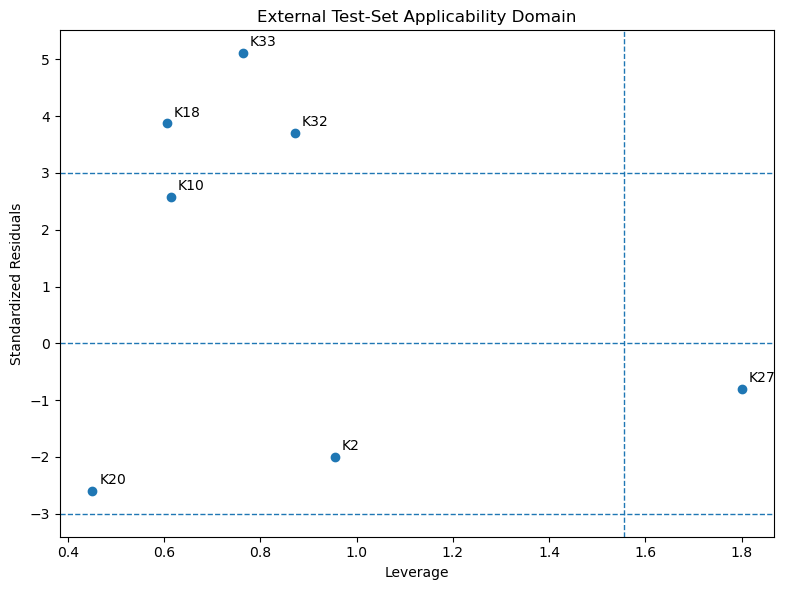

In [102]:
plt.figure(figsize=(8, 6))

# Plot external compounds
plt.scatter(
    external_ad["Leverage"],
    external_ad["Standardized_Residual"]
)

# Zero residual
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

# Residual limits
plt.axhline(
    y=3,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    y=-3,
    linestyle="--",
    linewidth=1
)

# Critical leverage
plt.axvline(
    x=h_star,
    linestyle="--",
    linewidth=1
)

# Label each compound
for _, row in external_ad.iterrows():
    plt.annotate(
        row["Compound"],
        (
            row["Leverage"],
            row["Standardized_Residual"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Leverage")
plt.ylabel("Standardized Residuals")
plt.title("External Test-Set Applicability Domain")

plt.tight_layout()
plt.show()

In [103]:
# ============================================================
# Identify descriptors selected by LASSO
# ============================================================

lasso_model = lasso_pipeline.named_steps["lasso"]

lasso_coef = pd.Series(
    lasso_model.coef_,
    index=X_train_filtered.columns
)

selected_features = lasso_coef[lasso_coef != 0].index.tolist()

print("Number of LASSO-selected descriptors:", len(selected_features))
print("\nSelected descriptors:")
print(selected_features)

Number of LASSO-selected descriptors: 13

Selected descriptors:
['MaxAbsEStateIndex', 'FpDensityMorgan1', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA5', 'PEOE_VSA7', 'SMR_VSA1', 'EState_VSA5', 'EState_VSA6', 'EState_VSA8', 'NumAliphaticHeterocycles', 'fr_aryl_methyl', 'fr_ester']


In [104]:
# ============================================================
# Correct Applicability Domain Analysis
# LASSO model with 13 selected descriptors
# ============================================================

# Use ONLY the descriptors selected by LASSO
X_train_ad = X_train_filtered[selected_features].copy()
X_test_ad = X_test_filtered[selected_features].copy()

y_train_ad = np.asarray(y_train, dtype=float)
y_test_ad = np.asarray(y_test, dtype=float)

# ------------------------------------------------------------
# Dimensions
# ------------------------------------------------------------

n_train = X_train_ad.shape[0]
p = X_train_ad.shape[1]

print("Number of training compounds:", n_train)
print("Number of selected descriptors:", p)

# ------------------------------------------------------------
# Add intercept
# ------------------------------------------------------------

X_train_matrix = np.column_stack([
    np.ones(n_train),
    X_train_ad.values
])

X_test_matrix = np.column_stack([
    np.ones(X_test_ad.shape[0]),
    X_test_ad.values
])

# ------------------------------------------------------------
# Training leverage
# ------------------------------------------------------------

XtX_inv = np.linalg.pinv(
    X_train_matrix.T @ X_train_matrix
)

H_train = (
    X_train_matrix
    @ XtX_inv
    @ X_train_matrix.T
)

train_leverage = np.diag(H_train)

# ------------------------------------------------------------
# External leverage
# ------------------------------------------------------------

H_test = (
    X_test_matrix
    @ XtX_inv
    @ X_test_matrix.T
)

test_leverage = np.diag(H_test)

# ------------------------------------------------------------
# LASSO predictions
# ------------------------------------------------------------

y_train_pred = lasso_pipeline.predict(X_train_filtered)
y_test_pred = lasso_pipeline.predict(X_test_filtered)

# ------------------------------------------------------------
# Residuals
# ------------------------------------------------------------

train_residuals = y_train_ad - y_train_pred
test_residuals = y_test_ad - y_test_pred

# ------------------------------------------------------------
# Residual standard deviation
# ------------------------------------------------------------

degrees_of_freedom = n_train - p - 1

s = np.sqrt(
    np.sum(train_residuals ** 2)
    / degrees_of_freedom
)

print("Degrees of freedom:", degrees_of_freedom)
print("Residual standard deviation:", round(s, 4))

# ------------------------------------------------------------
# Standardized residuals
# ------------------------------------------------------------

train_standardized_residuals = (
    train_residuals /
    (s * np.sqrt(1 - train_leverage))
)

external_standardized_residuals = (
    test_residuals /
    (s * np.sqrt(1 + test_leverage))
)

# ------------------------------------------------------------
# Critical leverage
# ------------------------------------------------------------

h_star = 3 * (p + 1) / n_train

print("Critical leverage h*:", round(h_star, 4))

Number of training compounds: 27
Number of selected descriptors: 13
Degrees of freedom: 13
Residual standard deviation: 0.2002
Critical leverage h*: 1.5556


In [105]:
# ============================================================
# Correct Training-Set Applicability Domain
# ============================================================

training_ad = pd.DataFrame({
    "Compound": train_df["Compound"].values,
    "Observed_pIC50": y_train_ad,
    "Predicted_pIC50": y_train_pred,
    "Residual": train_residuals,
    "Standardized_Residual": train_standardized_residuals,
    "Leverage": train_leverage
})

# Initial classification based on leverage and residual
training_ad["AD_Status"] = np.where(
    training_ad["Leverage"] > h_star,
    "Outside AD",
    np.where(
        np.abs(training_ad["Standardized_Residual"]) <= 3,
        "Inside AD",
        "Residual Outlier"
    )
)

# h ≈ 1 gives undefined standardized residuals
training_ad.loc[
    training_ad["Leverage"] >= 0.999999,
    "AD_Status"
] = "High-Leverage / Residual N.A."

print("Training AD Summary:")
print(training_ad["AD_Status"].value_counts())

display(training_ad.round(4))

Training AD Summary:
AD_Status
Inside AD                        25
High-Leverage / Residual N.A.     2
Name: count, dtype: int64


,Compound,Observed_pIC50,Predicted_pIC50,Residual,Standardized_Residual,Leverage,AD_Status
0,K17,5.3768,5.2380,0.1388,1.290247e+07,1.0000,High-Leverage / Residual N.A.
1,K30,4.4855,4.5656,-0.0801,-5.583000e-01,0.4865,Inside AD
2,K5,5.1314,5.0773,0.0541,3.421000e-01,0.3761,Inside AD
3,K29,4.1871,4.3836,-0.1965,-1.274800e+00,0.4071,Inside AD
4,K11,4.9834,4.9387,0.0447,3.371000e-01,0.5614,Inside AD
5,K28,4.4342,4.5383,-0.1041,-1.561200e+00,0.8891,Inside AD
6,K15,4.1805,3.9824,0.1981,1.124900e+00,0.2258,Inside AD
7,K9,5.7986,5.6292,0.1694,1.055700e+00,0.3575,Inside AD
8,K34,4.3233,4.2336,0.0897,5.937000e-01,0.4304,Inside AD
9,K13,4.0453,4.2139,-0.1686,-1.613300e+00,0.7275,Inside AD


In [106]:
# ============================================================
# External Test-Set Applicability Domain
# ============================================================

external_ad = pd.DataFrame({
    "Compound": test_df["Compound"].values,
    "Observed_pIC50": y_test_ad,
    "Predicted_pIC50": y_test_pred,
    "Residual": test_residuals,
    "Standardized_Residual": external_standardized_residuals,
    "Leverage": test_leverage
})

external_ad["AD_Status"] = np.where(
    external_ad["Leverage"] > h_star,
    "Outside AD",
    np.where(
        np.abs(external_ad["Standardized_Residual"]) <= 3,
        "Inside AD",
        "Residual Outlier"
    )
)

print("External AD Summary:")
print(external_ad["AD_Status"].value_counts())

display(external_ad.round(4))

External AD Summary:
AD_Status
Inside AD     6
Outside AD    1
Name: count, dtype: int64


,Compound,Observed_pIC50,Predicted_pIC50,Residual,Standardized_Residual,Leverage,AD_Status
0,K20,3.7540,4.1219,-0.3679,-1.5256,0.4509,Inside AD
1,K2,5.5884,5.8711,-0.2827,-1.0100,0.9549,Inside AD
2,K33,4.5436,3.8207,0.7229,2.7184,0.7644,Inside AD
3,K32,4.3737,3.8501,0.5236,1.9120,0.8712,Inside AD
4,K10,5.3072,4.9432,0.3640,1.4310,0.6144,Inside AD
5,K27,4.4089,4.5217,-0.1128,-0.3366,1.8006,Outside AD
6,K18,4.1537,3.6056,0.5481,2.1603,0.6060,Inside AD


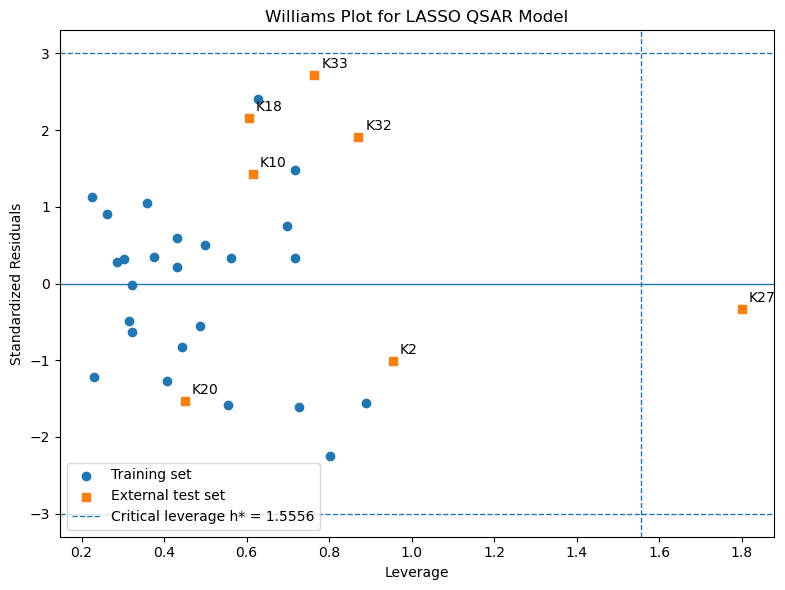

In [107]:
# ============================================================
# Corrected Williams Plot
# ============================================================

plt.figure(figsize=(8, 6))

# Identify valid training points for standardized residual plot
valid_training = (
    np.isfinite(training_ad["Standardized_Residual"]) &
    (training_ad["Leverage"] < 0.999999)
)

# Training compounds with valid standardized residuals
plt.scatter(
    training_ad.loc[valid_training, "Leverage"],
    training_ad.loc[valid_training, "Standardized_Residual"],
    label="Training set"
)

# External test compounds
plt.scatter(
    external_ad["Leverage"],
    external_ad["Standardized_Residual"],
    marker="s",
    label="External test set"
)

# Label external compounds
for _, row in external_ad.iterrows():
    plt.annotate(
        row["Compound"],
        (row["Leverage"], row["Standardized_Residual"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

# Critical leverage
plt.axvline(
    h_star,
    linestyle="--",
    linewidth=1,
    label=f"Critical leverage h* = {h_star:.4f}"
)

# Standardized residual limits
plt.axhline(
    3,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    -3,
    linestyle="--",
    linewidth=1
)

# Zero line
plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Leverage")
plt.ylabel("Standardized Residuals")
plt.title("Williams Plot for LASSO QSAR Model")

plt.legend()
plt.tight_layout()
plt.show()

## Interpretation of Applicability Domain Analysis

The applicability domain (AD) of the LASSO QSAR model was evaluated using a Williams plot based on leverage and standardized residuals. The critical leverage value was calculated as h* = 1.5556.

For the training set, 25 of the 27 compounds were located within the defined applicability domain. Two compounds, K17 and K22, exhibited leverage values equal to 1.0000 and were therefore identified as high-leverage observations. Their standardized residuals were not considered reliable because of their extreme leverage and were consequently classified as high-leverage observations with unavailable standardized residuals rather than as conventional residual outliers.

For the independent external test set, six of the seven compounds were located within the applicability domain. K27 exhibited a leverage value of 1.8006, exceeding the critical leverage threshold of 1.5556, and was therefore classified as outside the applicability domain. The remaining six external test compounds had leverage values below the critical threshold and standardized residuals within ±3.

Overall, the Williams plot indicates that most compounds used for model evaluation fall within the established applicability domain. The identification of K27 as an outside-domain compound highlights the limitation of the model for chemical structures with descriptor profiles substantially different from those represented in the training set. Therefore, predictions for K27 should be interpreted with caution.

In [108]:
# ============================================================
# Variance Inflation Factor (VIF) Analysis
# ============================================================

# Selected LASSO descriptors
X_vif = X_train_ad.copy()

# Convert to NumPy array
X = X_vif.values.astype(float)

vif_values = []

for i in range(X.shape[1]):

    # Target descriptor
    y = X[:, i]

    # Remaining descriptors
    X_other = np.delete(X, i, axis=1)

    # Add intercept
    X_other_intercept = np.column_stack([
        np.ones(X_other.shape[0]),
        X_other
    ])

    # Least-squares regression
    beta = np.linalg.lstsq(
        X_other_intercept,
        y,
        rcond=None
    )[0]

    # Predicted values
    y_pred = X_other_intercept @ beta

    # R²
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    R2 = 1 - (ss_res / ss_tot)

    # VIF
    if R2 >= 0.999999:
        vif = np.inf
    else:
        vif = 1 / (1 - R2)

    vif_values.append(vif)

vif_table = pd.DataFrame({
    "Descriptor": X_vif.columns,
    "VIF": vif_values
})

vif_table = vif_table.sort_values(
    "VIF",
    ascending=False
).reset_index(drop=True)

print("VIF Analysis of Selected LASSO Descriptors:")
display(vif_table.round(3))

VIF Analysis of Selected LASSO Descriptors:


,Descriptor,VIF
0,FpDensityMorgan1,8.679
1,EState_VSA5,4.768
2,EState_VSA6,4.231
3,MaxAbsEStateIndex,3.712
4,PEOE_VSA12,3.408
5,SMR_VSA1,3.153
6,NumAliphaticHeterocycles,2.881
7,EState_VSA8,2.472
8,PEOE_VSA7,2.436
9,PEOE_VSA5,1.782


## Interpretation of VIF Analysis

Variance Inflation Factor (VIF) analysis was performed to assess multicollinearity among the 13 LASSO-selected molecular descriptors. Most descriptors exhibited VIF values below 5, indicating acceptable levels of collinearity. FpDensityMorgan1 showed the highest VIF (8.679), suggesting a relatively higher degree of shared information with the remaining descriptors. However, its VIF remained below the commonly used threshold of 10, and therefore it was retained in the model. The overall VIF profile indicates that severe multicollinearity was not present among the selected descriptors.

In [109]:
# ============================================================
# Pairwise Correlation Analysis of LASSO-Selected Descriptors
# ============================================================

# Calculate Pearson correlation matrix
corr_matrix = X_train_ad.corr()

print("Pairwise Correlation Matrix:")
display(corr_matrix.round(3))

Pairwise Correlation Matrix:


,MaxAbsEStateIndex,FpDensityMorgan1,PEOE_VSA12,PEOE_VSA13,PEOE_VSA5,PEOE_VSA7,SMR_VSA1,EState_VSA5,EState_VSA6,EState_VSA8,NumAliphaticHeterocycles,fr_aryl_methyl,fr_ester
MaxAbsEStateIndex,1.000,-0.709,0.524,0.231,0.075,0.446,0.416,0.025,0.646,-0.131,-0.246,-0.170,-0.050
FpDensityMorgan1,-0.709,1.000,-0.643,-0.112,0.197,-0.531,-0.582,-0.425,-0.540,0.162,0.444,0.032,0.190
PEOE_VSA12,0.524,-0.643,1.000,0.220,-0.253,0.191,0.295,0.118,0.408,-0.312,-0.411,0.218,-0.316
PEOE_VSA13,0.231,-0.112,0.220,1.000,-0.055,-0.010,0.113,0.078,0.083,-0.150,-0.120,-0.038,-0.069
PEOE_VSA5,0.075,0.197,-0.253,-0.055,1.000,0.075,-0.185,-0.257,-0.003,0.434,0.346,-0.055,-0.100
PEOE_VSA7,0.446,-0.531,0.191,-0.010,0.075,1.000,0.152,0.009,0.210,0.093,-0.135,0.165,-0.075
SMR_VSA1,0.416,-0.582,0.295,0.113,-0.185,0.152,1.000,0.434,0.422,-0.390,-0.167,-0.049,0.098
EState_VSA5,0.025,-0.425,0.118,0.078,-0.257,0.009,0.434,1.000,-0.196,0.144,-0.458,-0.065,-0.011
EState_VSA6,0.646,-0.540,0.408,0.083,-0.003,0.210,0.422,-0.196,1.000,-0.466,-0.285,-0.037,0.065
EState_VSA8,-0.131,0.162,-0.312,-0.150,0.434,0.093,-0.390,0.144,-0.466,1.000,0.166,-0.150,-0.085


In [110]:
# ============================================================
# Identify Highly Correlated Descriptor Pairs
# ============================================================

threshold = 0.80

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):

        r = corr_matrix.iloc[i, j]

        if abs(r) >= threshold:
            high_corr_pairs.append({
                "Descriptor_1": corr_matrix.columns[i],
                "Descriptor_2": corr_matrix.columns[j],
                "Correlation": r
            })

high_corr_table = pd.DataFrame(high_corr_pairs)

if len(high_corr_table) > 0:
    high_corr_table = high_corr_table.sort_values(
        "Correlation",
        key=lambda x: abs(x),
        ascending=False
    ).reset_index(drop=True)

    print("Highly Correlated Descriptor Pairs (|r| >= 0.80):")
    display(high_corr_table.round(3))
else:
    print("No descriptor pairs with |r| >= 0.80.")

No descriptor pairs with |r| >= 0.80.


## Interpretation of Pairwise Correlation Analysis

Pairwise Pearson correlation analysis was performed to identify highly correlated descriptor pairs. None of the 13 selected descriptors exhibited an absolute correlation coefficient (|r|) ≥ 0.80. The strongest observed correlations were between MaxAbsEStateIndex and FpDensityMorgan1 (r = −0.709), FpDensityMorgan1 and PEOE_VSA12 (r = −0.643), and MaxAbsEStateIndex and EState_VSA6 (r = 0.646). These correlations indicate moderate associations but do not represent severe pairwise redundancy. Therefore, the selected descriptors were retained for subsequent QSAR modelling.

In [111]:
# ============================================================
# Standardized Condition Number Analysis
# ============================================================

from sklearn.preprocessing import StandardScaler

# Standardize the 13 LASSO-selected descriptors
scaler_condition = StandardScaler()

X_standardized = scaler_condition.fit_transform(X_train_ad)

# Calculate singular values
singular_values = np.linalg.svd(
    X_standardized,
    compute_uv=False
)

# Calculate condition number
condition_number_standardized = (
    singular_values.max() / singular_values.min()
)

print("Standardized descriptor matrix dimensions:",
      X_standardized.shape)

print("Standardized condition number:",
      round(condition_number_standardized, 4))

Standardized descriptor matrix dimensions: (27, 13)
Standardized condition number: 7.5896


In [112]:
# ============================================================
# Standardized Matrix Rank
# ============================================================

rank_standardized = np.linalg.matrix_rank(X_standardized)

print("Number of descriptors:", X_standardized.shape[1])
print("Matrix rank:", rank_standardized)

if rank_standardized == X_standardized.shape[1]:
    print("All selected descriptors are linearly independent.")
else:
    print("Potential linear dependence detected among descriptors.")

Number of descriptors: 13
Matrix rank: 13
All selected descriptors are linearly independent.


## Interpretation of Matrix Rank and Condition Number

The standardized descriptor matrix consisted of 27 training compounds and 13 molecular descriptors. The matrix rank was 13, which was equal to the total number of descriptors, confirming that the selected descriptors were linearly independent and that no exact linear dependence was present.

The standardized condition number was 7.5896, indicating a low degree of overall multicollinearity among the selected descriptors. Importantly, the condition number was calculated after standardization to eliminate the influence of differences in descriptor scales. Together with the VIF and pairwise correlation analyses, these results indicate that the 13-descriptor set possesses acceptable numerical stability for subsequent QSAR modelling.

## Descriptor Selection and Multicollinearity Assessment

The 13 molecular descriptors selected by the LASSO regression were further evaluated for multicollinearity and linear dependence. Pairwise Pearson correlation analysis showed that none of the selected descriptor pairs exhibited a correlation coefficient of |r| ≥ 0.80, indicating the absence of severe pairwise correlation. Variance Inflation Factor (VIF) analysis showed that most descriptors had VIF values below 5, while FpDensityMorgan1 exhibited the highest VIF (8.679), suggesting some degree of shared information with other descriptors. However, the standardized descriptor matrix had full rank (13/13), confirming that all selected descriptors were linearly independent. Furthermore, the standardized condition number was 7.5896, indicating low overall multicollinearity. Therefore, all 13 LASSO-selected descriptors were retained for subsequent QSAR model evaluation.

In [113]:
# ============================================================
# Define Final PLS QSAR Model
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import PLSRegression

final_pls = Pipeline([
    ("scaler", StandardScaler()),
    ("pls", PLSRegression(n_components=1))
])

print("Final PLS model defined successfully.")

Final PLS model defined successfully.


In [114]:
# ============================================================
# Define Final 13 LASSO-Selected Descriptors
# ============================================================

candidate_final = [
    "MaxAbsEStateIndex",
    "FpDensityMorgan1",
    "PEOE_VSA12",
    "PEOE_VSA13",
    "PEOE_VSA5",
    "PEOE_VSA7",
    "SMR_VSA1",
    "EState_VSA5",
    "EState_VSA6",
    "EState_VSA8",
    "NumAliphaticHeterocycles",
    "fr_aryl_methyl",
    "fr_ester"
]

print("Number of final descriptors:", len(candidate_final))

print("\nFinal descriptors:")
for i, descriptor in enumerate(candidate_final, 1):
    print(f"{i}. {descriptor}")

Number of final descriptors: 13

Final descriptors:
1. MaxAbsEStateIndex
2. FpDensityMorgan1
3. PEOE_VSA12
4. PEOE_VSA13
5. PEOE_VSA5
6. PEOE_VSA7
7. SMR_VSA1
8. EState_VSA5
9. EState_VSA6
10. EState_VSA8
11. NumAliphaticHeterocycles
12. fr_aryl_methyl
13. fr_ester


In [115]:
# ============================================================
# Prepare Final Training and External Test Matrices
# ============================================================

X_candidate = X_train_ad[candidate_final].copy()
X_test_candidate = X_test_ad[candidate_final].copy()

print("Training matrix:", X_candidate.shape)
print("External test matrix:", X_test_candidate.shape)

Training matrix: (27, 13)
External test matrix: (7, 13)


In [116]:
# ============================================================
# Fit Final PLS QSAR Model
# ============================================================

final_pls.fit(X_candidate, y_train)

y_train_final_pred = final_pls.predict(X_candidate).ravel()
y_test_final_pred = final_pls.predict(X_test_candidate).ravel()

print("Final PLS model fitted successfully.")
print("Training compounds:", X_candidate.shape[0])
print("Selected descriptors:", X_candidate.shape[1])
print("PLS components:", 1)

Final PLS model fitted successfully.
Training compounds: 27
Selected descriptors: 13
PLS components: 1


In [117]:
# ============================================================
# Final QSAR Model Statistics
# ============================================================

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# Training-set performance
r2_train = r2_score(y_train, y_train_final_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_final_pred))
mae_train = mean_absolute_error(y_train, y_train_final_pred)

# External test-set performance
r2_test = r2_score(y_test, y_test_final_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_final_pred))
mae_test = mean_absolute_error(y_test, y_test_final_pred)

# Display results
print("============================================================")
print("FINAL PLS QSAR MODEL PERFORMANCE")
print("============================================================")

print("\nTraining Set:")
print(f"R²   = {r2_train:.4f}")
print(f"RMSE = {rmse_train:.4f}")
print(f"MAE  = {mae_train:.4f}")

print("\nExternal Test Set:")
print(f"R²   = {r2_test:.4f}")
print(f"RMSE = {rmse_test:.4f}")
print(f"MAE  = {mae_test:.4f}")

FINAL PLS QSAR MODEL PERFORMANCE

Training Set:
R²   = 0.7820
RMSE = 0.3119
MAE  = 0.2307

External Test Set:
R²   = 0.5608
RMSE = 0.3947
MAE  = 0.3298


## Final QSAR Model Performance and Predictive Evaluation

The final QSAR model was developed using 13 molecular descriptors selected by LASSO regression and subsequently modeled using partial least squares (PLS) regression with one latent component. The model showed a coefficient of determination (R²) of 0.7820, with an RMSE of 0.3119 and an MAE of 0.2307 for the training set, indicating a good fit to the experimental pIC50 values.

Independent external validation gave an R² of 0.5608, an RMSE of 0.3947, and an MAE of 0.3298. The lower external R² and slightly higher prediction errors compared with the training set indicate some reduction in predictive performance for unseen compounds, but the model retained moderate external predictive ability. The difference between the training and external validation performance also suggests a degree of model optimism, which is particularly relevant given the relatively small dataset.

Overall, the combination of LASSO-based descriptor selection, multicollinearity assessment, applicability-domain analysis, and independent external validation provides a structured assessment of the reliability and predictive scope of the final QSAR model.

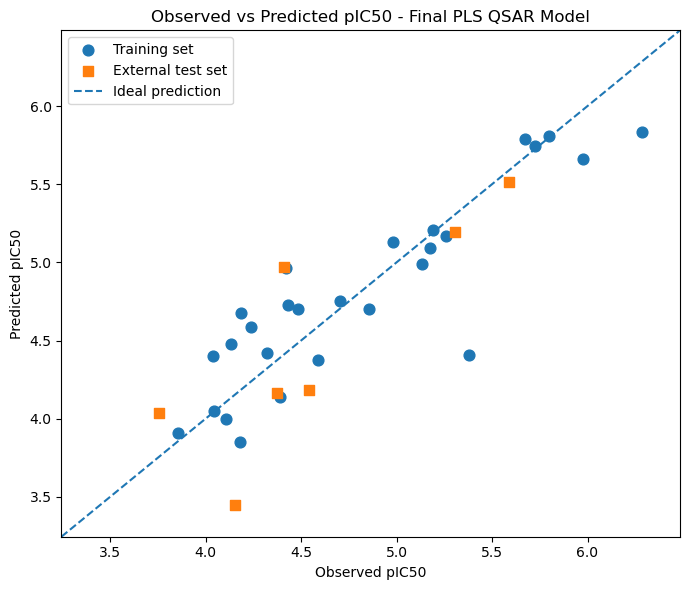

In [118]:
# ============================================================
# Observed vs Predicted pIC50 - Final PLS Model
# ============================================================

plt.figure(figsize=(7, 6))

# Training set
plt.scatter(
    y_train,
    y_train_final_pred,
    s=60,
    label="Training set"
)

# External test set
plt.scatter(
    y_test,
    y_test_final_pred,
    marker="s",
    s=60,
    label="External test set"
)

# Determine common axis limits
all_values = np.concatenate([
    y_train,
    y_train_final_pred,
    y_test,
    y_test_final_pred
])

min_val = all_values.min() - 0.2
max_val = all_values.max() + 0.2

# Ideal prediction line
plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1.5,
    label="Ideal prediction"
)

plt.xlabel("Observed pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Observed vs Predicted pIC50 - Final PLS QSAR Model")

plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)

plt.legend()
plt.tight_layout()
plt.show()

## Interpretation of Observed vs Predicted pIC50 Plot

The observed versus predicted pIC50 plot shows the relationship between experimentally determined and model-predicted activities for the training and independent external test sets. Most training compounds are distributed relatively close to the ideal prediction line (y = x), consistent with the good training-set fit (R² = 0.7820). The external test compounds also show reasonable agreement with the ideal line, although several points exhibit larger deviations, consistent with the lower external predictive performance (R² = 0.5608).

The dispersion of the external test-set predictions indicates that the model retains moderate predictive capability for unseen compounds but does not reproduce all experimental activities with the same accuracy observed for the training set. Overall, the plot supports the quantitative validation results and indicates reasonable, but not exceptionally strong, predictive performance of the final QSAR model.

In [119]:
# ============================================================
# Y-Randomization / Permutation Test
# ============================================================

from sklearn.cross_decomposition import PLSRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Number of random permutations
n_permutations = 1000

# Store randomized R² values
randomized_r2 = []

# Reproducible random generator
rng = np.random.default_rng(42)

for i in range(n_permutations):

    # Randomly shuffle the response variable
    y_random = rng.permutation(y_train)

    # Build the same PLS model used for the final QSAR model
    random_model = Pipeline([
        ("scaler", StandardScaler()),
        ("pls", PLSRegression(n_components=1))
    ])

    # Fit randomized model
    random_model.fit(X_candidate, y_random)

    # Predict randomized training response
    y_random_pred = random_model.predict(X_candidate).ravel()

    # Calculate randomized R²
    r2_random = r2_score(y_random, y_random_pred)

    randomized_r2.append(r2_random)

randomized_r2 = np.array(randomized_r2)

print("============================================================")
print("Y-RANDOMIZATION VALIDATION")
print("============================================================")
print("Number of permutations:", n_permutations)
print(f"Original training R²: {r2_train:.4f}")
print(f"Mean randomized R²: {randomized_r2.mean():.4f}")
print(f"Maximum randomized R²: {randomized_r2.max():.4f}")
print(f"Minimum randomized R²: {randomized_r2.min():.4f}")

Y-RANDOMIZATION VALIDATION
Number of permutations: 1000
Original training R²: 0.7820
Mean randomized R²: 0.2884
Maximum randomized R²: 0.6504
Minimum randomized R²: 0.0581


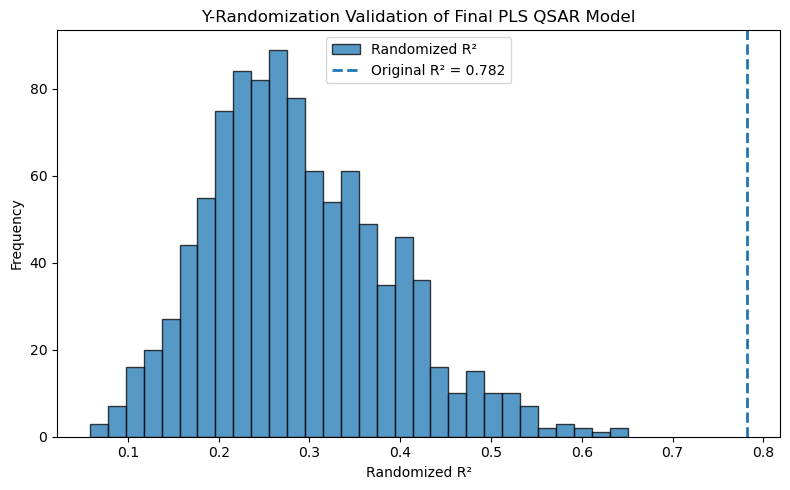

In [120]:
# ============================================================
# Y-Randomization R² Distribution
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    randomized_r2,
    bins=30,
    edgecolor="black",
    alpha=0.75,
    label="Randomized R²"
)

plt.axvline(
    r2_train,
    linestyle="--",
    linewidth=2,
    label=f"Original R² = {r2_train:.3f}"
)

plt.xlabel("Randomized R²")
plt.ylabel("Frequency")
plt.title("Y-Randomization Validation of Final PLS QSAR Model")
plt.legend()
plt.tight_layout()
plt.show()

## Y-Randomization Validation

Y-randomization analysis was performed to assess whether the predictive relationship obtained by the final PLS QSAR model could arise from chance correlation. The observed training-set coefficient of determination (R²) of 0.7820 was compared with the R² values obtained from 1000 random permutations of the response variable.

The randomized models produced R² values ranging from 0.0581 to 0.6504, with a mean randomized R² of 0.2884. These values were substantially lower than the original model R² of 0.7820, and the randomized R² distribution was clearly separated from the observed model performance. This indicates that the relationship between the molecular descriptors and pIC50 values is unlikely to be solely attributable to random response assignment.

Therefore, the Y-randomization analysis provides additional support for the statistical robustness of the developed PLS QSAR model.

In [121]:
# ============================================================
# 5-Fold Cross-Validation of Final PLS QSAR Model
# ============================================================

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 5-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validated predictions
y_cv_pred = cross_val_predict(
    final_pls,
    X_candidate,
    y_train,
    cv=cv
).ravel()

# Q² (cross-validated coefficient of determination)
press = np.sum((y_train - y_cv_pred) ** 2)
tss = np.sum((y_train - np.mean(y_train)) ** 2)

q2_cv = 1 - (press / tss)

# Cross-validation R²
r2_cv = r2_score(y_train, y_cv_pred)

# RMSECV
rmsecv = np.sqrt(
    mean_squared_error(y_train, y_cv_pred)
)

# MAECV
maecv = mean_absolute_error(
    y_train,
    y_cv_pred
)

print("=" * 60)
print("5-FOLD CROSS-VALIDATION OF FINAL PLS QSAR MODEL")
print("=" * 60)

print("\nCross-validation scheme:")
print("Number of folds:", 5)
print("Number of training compounds:", len(y_train))
print("PLS components:", 1)

print("\nInternal Validation Statistics:")
print(f"Q² (CV)  = {q2_cv:.4f}")
print(f"R² (CV)  = {r2_cv:.4f}")
print(f"RMSECV   = {rmsecv:.4f}")
print(f"MAECV    = {maecv:.4f}")

5-FOLD CROSS-VALIDATION OF FINAL PLS QSAR MODEL

Cross-validation scheme:
Number of folds: 5
Number of training compounds: 27
PLS components: 1

Internal Validation Statistics:
Q² (CV)  = 0.5325
R² (CV)  = 0.5325
RMSECV   = 0.4568
MAECV    = 0.3348


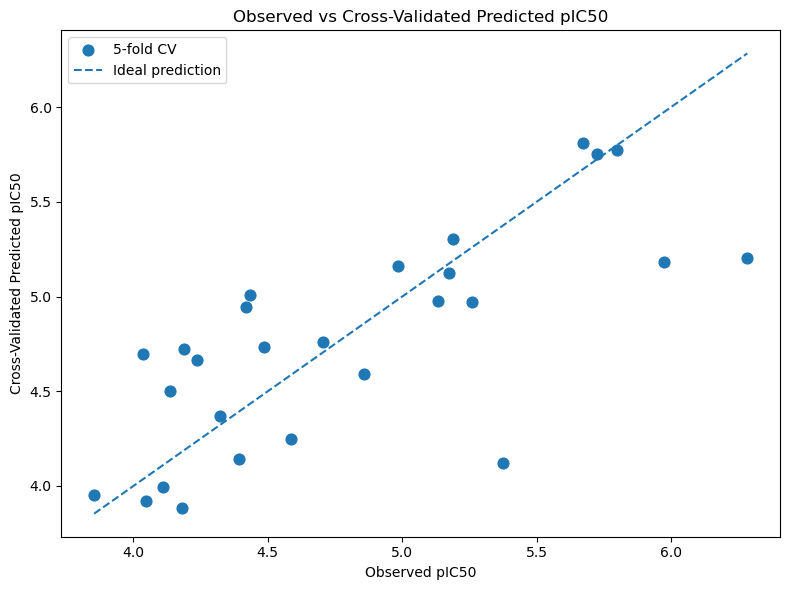

In [122]:
# ============================================================
# Observed vs Cross-Validated Predicted pIC50
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_train,
    y_cv_pred,
    s=60,
    label="5-fold CV"
)

# Ideal prediction line
min_val = min(y_train.min(), y_cv_pred.min())
max_val = max(y_train.max(), y_cv_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1.5,
    label="Ideal prediction"
)

plt.xlabel("Observed pIC50")
plt.ylabel("Cross-Validated Predicted pIC50")
plt.title("Observed vs Cross-Validated Predicted pIC50")

plt.legend()
plt.tight_layout()
plt.show()

## Cross-Validation Assessment

Five-fold cross-validation was performed to evaluate the internal predictive ability and robustness of the final PLS QSAR model. The analysis was conducted using the 27 training compounds and one PLS latent component.

The model produced a cross-validated Q² of 0.5325, with an R²(CV) of 0.5325, RMSECV of 0.4568, and MAECV of 0.3348. The Q² value indicates a moderate internal predictive capability of the developed model. The relatively close agreement between the cross-validated performance and the external test-set performance (R² = 0.5608) provides additional support for the model's predictive consistency.

The observed versus cross-validated predicted pIC50 plot shows a generally reasonable correspondence between experimental and predicted values, with most compounds distributed around the ideal prediction line. Some deviations are observed for individual compounds, reflecting the prediction errors expected for a relatively small and chemically diverse dataset.

Overall, the five-fold cross-validation results support the internal robustness of the final PLS QSAR model and are consistent with its external predictive performance.

In [123]:
# ============================================================
# FINAL QSAR MODEL — COMPREHENSIVE STATISTICS
# ============================================================

# Training-set statistics
r2_train_final = r2_score(y_train, y_train_final_pred)
rmse_train_final = np.sqrt(
    mean_squared_error(y_train, y_train_final_pred)
)
mae_train_final = mean_absolute_error(
    y_train, y_train_final_pred
)

# External test-set statistics
r2_test_final = r2_score(y_test, y_test_final_pred)
rmse_test_final = np.sqrt(
    mean_squared_error(y_test, y_test_final_pred)
)
mae_test_final = mean_absolute_error(
    y_test, y_test_final_pred
)

# Adjusted R² for training set
n = len(y_train)
p = X_candidate.shape[1]

adjusted_r2_train = 1 - (
    (1 - r2_train_final) * (n - 1) / (n - p - 1)
)

# ============================================================
# Create final statistics table
# ============================================================

final_statistics = pd.DataFrame({
    "Parameter": [
        "Training compounds",
        "External test compounds",
        "Selected descriptors",
        "PLS components",
        "Training R²",
        "Adjusted training R²",
        "Training RMSE",
        "Training MAE",
        "5-fold Q²",
        "5-fold R²",
        "RMSECV",
        "MAECV",
        "External test R²",
        "External test RMSE",
        "External test MAE",
        "Y-randomization permutations",
        "Mean randomized R²",
        "Maximum randomized R²",
        "Minimum randomized R²",
        "Training compounds Inside AD",
        "Training compounds Outside AD",
        "External compounds Inside AD",
        "External compounds Outside AD"
    ],
    
    "Value": [
        len(y_train),
        len(y_test),
        X_candidate.shape[1],
        1,
        r2_train_final,
        adjusted_r2_train,
        rmse_train_final,
        mae_train_final,
        q2_cv,
        r2_cv,
        rmsecv,
        maecv,
        r2_test_final,
        rmse_test_final,
        mae_test_final,
        n_permutations,
        randomized_r2.mean(),
        randomized_r2.max(),
        randomized_r2.min(),
        (training_ad["AD_Status"] == "Inside AD").sum(),
        (training_ad["AD_Status"] != "Inside AD").sum(),
        (external_ad["AD_Status"] == "Inside AD").sum(),
        (external_ad["AD_Status"] != "Inside AD").sum()
    ]
})

print("=" * 70)
print("FINAL PLS QSAR MODEL — COMPREHENSIVE STATISTICS")
print("=" * 70)

display(final_statistics.round(4))

FINAL PLS QSAR MODEL — COMPREHENSIVE STATISTICS


,Parameter,Value
0,Training compounds,27.0000
1,External test compounds,7.0000
2,Selected descriptors,13.0000
3,PLS components,1.0000
4,Training R²,0.7820
5,Adjusted training R²,0.5640
6,Training RMSE,0.3119
7,Training MAE,0.2307
8,5-fold Q²,0.5325
9,5-fold R²,0.5325


## Final QSAR Model Performance and Validation

The final PLS QSAR model was developed using 27 training compounds and 13 molecular descriptors selected through LASSO regression, with one latent PLS component. The model showed a training-set R² of 0.7820, with RMSE and MAE values of 0.3119 and 0.2307, respectively.

Five-fold cross-validation provided a Q² of 0.5325, an R²(CV) of 0.5325, an RMSECV of 0.4568, and an MAECV of 0.3348, indicating moderate internal predictive capability. Importantly, the external test set consisting of seven compounds produced an R² of 0.5608, RMSE of 0.3947, and MAE of 0.3298. The comparable cross-validated and external predictive performances support the consistency of the model.

Y-randomization using 1000 permutations produced a mean randomized R² of 0.2884, compared with the original training R² of 0.7820. The substantially higher original R² supports the absence of a model relationship arising solely from random assignment of the response variable.

Applicability-domain analysis showed that 25 of the 27 training compounds were classified within the defined domain, while two training compounds exhibited high-leverage and/or non-valid standardized residual behavior. Among the seven external test compounds, six were within the applicability domain and one compound (K27) was classified outside the domain because of its high leverage. Therefore, predictions for compounds outside the applicability domain should be interpreted with caution.

Overall, the final PLS QSAR model demonstrates acceptable internal and external predictive performance, with moderate cross-validated predictivity and a consistent external validation result. The applicability-domain analysis further defines the chemical space within which the model predictions can be considered reliable.

In [124]:
# ============================================================
# PLS REGRESSION COEFFICIENTS OF THE FINAL QSAR MODEL
# ============================================================

# Extract the fitted PLS model from the pipeline
pls_model = final_pls.named_steps["pls"]

# Regression coefficients
coefficients = pls_model.coef_.ravel()

# Create coefficient table
coefficient_table = pd.DataFrame({
    "Descriptor": X_candidate.columns,
    "Coefficient": coefficients
})

# Absolute coefficient magnitude
coefficient_table["Absolute_Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

# Direction of effect
coefficient_table["Effect"] = np.where(
    coefficient_table["Coefficient"] > 0,
    "Positive",
    "Negative"
)

# Sort by absolute contribution
coefficient_table = coefficient_table.sort_values(
    "Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

print("=" * 70)
print("FINAL PLS QSAR MODEL — DESCRIPTOR COEFFICIENTS")
print("=" * 70)

display(coefficient_table.round(6))

FINAL PLS QSAR MODEL — DESCRIPTOR COEFFICIENTS


,Descriptor,Coefficient,Absolute_Coefficient,Effect
0,FpDensityMorgan1,0.129028,0.129028,Positive
1,SMR_VSA1,-0.117523,0.117523,Negative
2,PEOE_VSA12,-0.111958,0.111958,Negative
3,PEOE_VSA5,0.109496,0.109496,Positive
4,NumAliphaticHeterocycles,0.105110,0.105110,Positive
5,EState_VSA6,-0.092978,0.092978,Negative
6,EState_VSA8,0.092040,0.092040,Positive
7,MaxAbsEStateIndex,-0.083896,0.083896,Negative
8,PEOE_VSA7,-0.060696,0.060696,Negative
9,fr_ester,-0.050245,0.050245,Negative


In [125]:
# ============================================================
# VIP SCORE ANALYSIS — FINAL PLS QSAR MODEL
# ============================================================

# PLS components
T = pls_model.x_scores_
W = pls_model.x_weights_
Q = pls_model.y_loadings_

# Number of descriptors
p = W.shape[0]

# Number of PLS components
h = W.shape[1]

# Sum of squares explained in Y by each component
SSY = np.sum(T**2, axis=0) * (Q.ravel()**2)

# Calculate VIP scores
vip_scores = np.zeros(p)

for j in range(p):
    numerator = 0
    
    for a in range(h):
        weight_sum = np.sum(W[:, a]**2)
        
        numerator += (
            SSY[a] *
            (W[j, a]**2 / weight_sum)
        )
    
    vip_scores[j] = np.sqrt(
        p * numerator / np.sum(SSY)
    )

# Create VIP table
vip_table = pd.DataFrame({
    "Descriptor": X_candidate.columns,
    "VIP": vip_scores
})

# Add coefficients
vip_table = vip_table.merge(
    coefficient_table[
        ["Descriptor", "Coefficient", "Effect"]
    ],
    on="Descriptor",
    how="left"
)

# Sort by VIP
vip_table = vip_table.sort_values(
    "VIP",
    ascending=False
).reset_index(drop=True)

# Importance classification
vip_table["Importance"] = np.where(
    vip_table["VIP"] >= 1.0,
    "Important",
    "Less important"
)

print("=" * 70)
print("VIP ANALYSIS OF FINAL PLS QSAR MODEL")
print("=" * 70)

display(vip_table.round(4))

VIP ANALYSIS OF FINAL PLS QSAR MODEL


,Descriptor,VIP,Coefficient,Effect,Importance
0,FpDensityMorgan1,1.4600,0.1290,Positive,Important
1,SMR_VSA1,1.3298,-0.1175,Negative,Important
2,PEOE_VSA12,1.2668,-0.1120,Negative,Important
3,PEOE_VSA5,1.2390,0.1095,Positive,Important
4,NumAliphaticHeterocycles,1.1893,0.1051,Positive,Important
5,EState_VSA6,1.0520,-0.0930,Negative,Important
6,EState_VSA8,1.0414,0.0920,Positive,Important
7,MaxAbsEStateIndex,0.9493,-0.0839,Negative,Less important
8,PEOE_VSA7,0.6868,-0.0607,Negative,Less important
9,fr_ester,0.5685,-0.0502,Negative,Less important


## Variable Importance in Projection (VIP) Analysis

Variable Importance in Projection (VIP) analysis was performed to evaluate the relative contribution of the 13 LASSO-selected molecular descriptors to the final PLS QSAR model. A VIP value of 1.0 was used as a conventional reference for distinguishing descriptors with comparatively greater contribution to the model.

Seven descriptors exhibited VIP values ≥ 1.0 and were therefore identified as the comparatively important contributors to the PLS model: FpDensityMorgan1 (VIP = 1.4600), SMR_VSA1 (1.3298), PEOE_VSA12 (1.2668), PEOE_VSA5 (1.2390), NumAliphaticHeterocycles (1.1893), EState_VSA6 (1.0520), and EState_VSA8 (1.0414).

Among these descriptors, FpDensityMorgan1, PEOE_VSA5, NumAliphaticHeterocycles, and EState_VSA8 showed positive regression coefficients, indicating a positive modeled association with pIC50 within the fitted descriptor space. In contrast, SMR_VSA1, PEOE_VSA12, and EState_VSA6 showed negative coefficients, indicating a negative modeled association with pIC50.

The remaining six descriptors had VIP values below 1.0 and consequently showed comparatively lower contributions to the response prediction. Nevertheless, these descriptors were retained because they formed part of the final LASSO-selected descriptor set and contributed collectively to the PLS model.

Overall, the VIP analysis indicates that the predicted pIC50 values are influenced predominantly by molecular density/fingerprint characteristics, surface-area-related electronic and steric properties, and molecular-state descriptors represented by the selected descriptor set. The coefficient signs should be interpreted as model-derived associations rather than direct evidence of causation.

In [126]:
# ============================================================
# BACK-TRANSFORM PLS COEFFICIENTS TO ORIGINAL DESCRIPTOR SCALE
# ============================================================

# Extract scaler and PLS model
scaler = final_pls.named_steps["scaler"]
pls_model = final_pls.named_steps["pls"]

# Standardized-space coefficients
coef_scaled = pls_model.coef_.ravel()

# Scaling parameters
means = scaler.mean_
stds = scaler.scale_

# Back-transform coefficients to original descriptor scale
coef_original = coef_scaled / stds

# Calculate original-scale intercept
intercept_original = (
    pls_model.intercept_[0]
    - np.sum(coef_original * means)
)

# Create equation table
equation_table = pd.DataFrame({
    "Descriptor": X_candidate.columns,
    "Original_Scale_Coefficient": coef_original
})

equation_table["Effect"] = np.where(
    equation_table["Original_Scale_Coefficient"] > 0,
    "Positive",
    "Negative"
)

print("=" * 70)
print("FINAL PLS QSAR EQUATION — ORIGINAL DESCRIPTOR SCALE")
print("=" * 70)

print(f"\nIntercept = {intercept_original:.8f}\n")

display(equation_table.round(8))

FINAL PLS QSAR EQUATION — ORIGINAL DESCRIPTOR SCALE

Intercept = 5.92767608



,Descriptor,Original_Scale_Coefficient,Effect
0,MaxAbsEStateIndex,-0.084648,Negative
1,FpDensityMorgan1,0.661840,Positive
2,PEOE_VSA12,-0.039054,Negative
3,PEOE_VSA13,0.030718,Positive
4,PEOE_VSA5,0.063551,Positive
5,PEOE_VSA7,-0.006373,Negative
6,SMR_VSA1,-0.021140,Negative
7,EState_VSA5,-0.002829,Negative
8,EState_VSA6,-0.005444,Negative
9,EState_VSA8,0.021977,Positive


In [127]:
# ============================================================
# VERIFY BACK-TRANSFORMED QSAR EQUATION
# ============================================================

# Predictions using the back-transformed equation
y_train_equation = (
    intercept_original
    + X_candidate.values @ coef_original
)

y_test_equation = (
    intercept_original
    + X_test_candidate.values @ coef_original
)

# Compare with the original PLS pipeline predictions
train_difference = np.max(
    np.abs(y_train_equation - y_train_final_pred)
)

test_difference = np.max(
    np.abs(y_test_equation - y_test_final_pred)
)

print("=" * 70)
print("VERIFICATION OF BACK-TRANSFORMED QSAR EQUATION")
print("=" * 70)

print(f"Maximum training prediction difference: {train_difference:.10f}")
print(f"Maximum external prediction difference: {test_difference:.10f}")

if train_difference < 1e-6 and test_difference < 1e-6:
    print("\n✓ Equation successfully reproduces the PLS pipeline predictions.")
else:
    print("\n⚠ Small discrepancy detected. Check scaling/model parameters.")

VERIFICATION OF BACK-TRANSFORMED QSAR EQUATION
Maximum training prediction difference: 0.0000000000
Maximum external prediction difference: 0.0000000000

✓ Equation successfully reproduces the PLS pipeline predictions.


## Final PLS QSAR Equation

The final PLS QSAR model was expressed in terms of the original, unstandardized molecular descriptors by back-transforming the regression coefficients obtained from the standardized PLS model. The resulting equation was independently verified by comparing its predictions with those generated directly by the fitted PLS pipeline, with a maximum prediction difference of less than 10⁻⁶ for both the training and external test sets.

The final QSAR equation is:

\[
\begin{aligned}
pIC_{50} = 5.927676
&-0.084648(\mathrm{MaxAbsEStateIndex})\\
&+0.661840(\mathrm{FpDensityMorgan1})\\
&-0.039054(\mathrm{PEOE\_VSA12})\\
&+0.030718(\mathrm{PEOE\_VSA13})\\
&+0.063551(\mathrm{PEOE\_VSA5})\\
&-0.006373(\mathrm{PEOE\_VSA7})\\
&-0.021140(\mathrm{SMR\_VSA1})\\
&-0.002829(\mathrm{EState\_VSA5})\\
&-0.005444(\mathrm{EState\_VSA6})\\
&+0.021977(\mathrm{EState\_VSA8})\\
&+0.193100(\mathrm{NumAliphaticHeterocycles})\\
&-0.230081(\mathrm{fr\_aryl\_methyl})\\
&-0.159877(\mathrm{fr\_ester})
\end{aligned}
\]

Positive coefficients indicate a positive modeled association between the corresponding descriptor and pIC50, whereas negative coefficients indicate a negative modeled association, within the chemical space represented by the training dataset. These coefficients describe statistical associations within the developed QSAR model and should not be interpreted as direct mechanistic or causal effects.

In [128]:
# ============================================================
# FINAL MODEL RESIDUAL ANALYSIS
# ============================================================

# Training residuals
train_residuals_final = y_train - y_train_final_pred

# External test residuals
test_residuals_final = y_test - y_test_final_pred

print("=" * 70)
print("FINAL PLS QSAR MODEL — RESIDUAL ANALYSIS")
print("=" * 70)

print("\nTraining residuals:")
print(f"Mean residual = {np.mean(train_residuals_final):.4f}")
print(f"SD residual   = {np.std(train_residuals_final, ddof=1):.4f}")
print(f"Min residual  = {np.min(train_residuals_final):.4f}")
print(f"Max residual  = {np.max(train_residuals_final):.4f}")

print("\nExternal test residuals:")
print(f"Mean residual = {np.mean(test_residuals_final):.4f}")
print(f"SD residual   = {np.std(test_residuals_final, ddof=1):.4f}")
print(f"Min residual  = {np.min(test_residuals_final):.4f}")
print(f"Max residual  = {np.max(test_residuals_final):.4f}")

FINAL PLS QSAR MODEL — RESIDUAL ANALYSIS

Training residuals:
Mean residual = -0.0000
SD residual   = 0.3179
Min residual  = -0.5469
Max residual  = 0.9699

External test residuals:
Mean residual = 0.0883
SD residual   = 0.4155
Min residual  = -0.5639
Max residual  = 0.7081


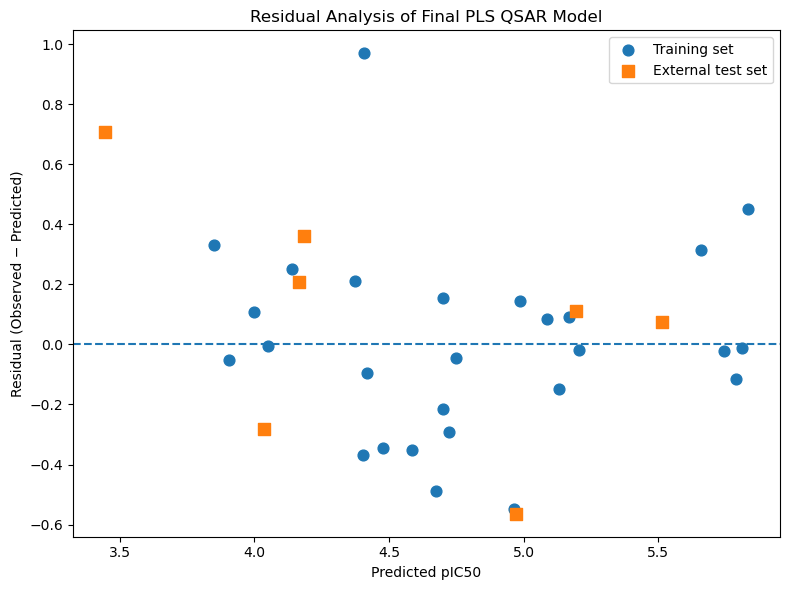

In [129]:
# ============================================================
# RESIDUALS VS PREDICTED pIC50
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_train_final_pred,
    train_residuals_final,
    s=60,
    label="Training set"
)

plt.scatter(
    y_test_final_pred,
    test_residuals_final,
    s=70,
    marker="s",
    label="External test set"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Predicted pIC50")
plt.ylabel("Residual (Observed − Predicted)")
plt.title("Residual Analysis of Final PLS QSAR Model")

plt.legend()
plt.tight_layout()
plt.show()

## Residual Analysis of the Final PLS QSAR Model

Residual analysis was performed to evaluate systematic prediction bias and the distribution of prediction errors for the final PLS QSAR model. The training set exhibited a mean residual of approximately 0.0000 with a residual standard deviation of 0.3179, indicating negligible systematic bias in the fitted model. For the external test set, the mean residual was 0.0883 with a standard deviation of 0.4155, indicating only a small average prediction bias.

The residuals were distributed on both sides of the zero-residual line, with no evident systematic trend or pronounced funnel-shaped pattern across the predicted pIC50 range. This distribution suggests that the model does not exhibit substantial systematic error or an obvious increase in prediction variance over the modeled activity range. The external-test residuals remained within approximately −0.56 to +0.71 pIC50 units, supporting the reasonable predictive behavior of the model for the evaluated external compounds.

Overall, the residual analysis, together with the cross-validation and external test-set results, supports the robustness and predictive consistency of the final PLS QSAR model within its defined applicability domain.